In [1]:
import pandas as pd
import numpy as np
from scipy.stats import chisquare
import re
# Librerías gráficas
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y Modelado
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder,MinMaxScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# GUardado del modelo
import joblib

# Configuración global
np.random.seed(1989)
pd.set_option("display.float_format", '{:,.2f}'.format)

print("Bibliotecas importadas correctamente.")

Bibliotecas importadas correctamente.


In [2]:
df_i = pd.read_csv("../imputacion/dataset_laptops_mexico_enriquecidos.csv")

In [3]:
#df_raw = pd.read_csv("../datos_crudos/dataset_laptops_mexico.csv")

In [4]:
#df_raw.head()

In [5]:
df_i.head()

,ID_Global,Tienda,ID_Producto,Marca,Nombre,Precio_MXN,RAM_GB,Almacenamiento_GB,Tipo_Almacenamiento,Procesador,GPU_Dedicada,Pantalla_Pulgadas,URL_Producto,Ruta_Imagen_Local,Procesador_Modelo,Numero_Nucleos,Generacion_CPU
0,MX-00000,Chedraui,CHE-0000,Hp,"Laptop HP 9W149LA R5/512GB/8GB/15.6""","14,995.00",512.00,512.00,SSD,No especificado,0,15.60,https://www.chedraui.com.mx/laptop-hp-9w149la-...,NaN,No especificado,No especificado,No especificado
1,MX-00001,Chedraui,CHE-0001,Lenovo,Laptop Lenovo 82XB001GLM Cel 8G 256 SSD 15.6 P...,"13,495.00",NaN,NaN,SSD,No especificado,0,15.60,https://www.chedraui.com.mx/laptop-lenovo-82xb...,NaN,No especificado,No especificado,No especificado
2,MX-00002,Chedraui,CHE-0002,Acer,Laptop Acer Aspire Lite 15.6 Pulgadas FHD Core...,"17,495.00",16.00,16.00,SSD,Core I5,0,15.60,https://www.chedraui.com.mx/laptop-acer-aspire...,NaN,Intel Core i5,No especificado,No especificado
3,MX-00003,Chedraui,CHE-0003,Hp,"Laptop HP 255 G10 de 15,6 Pulgadas Windows 11 ...","8,495.00",8.00,8.00,SSD,Ryzen 3,0,NaN,https://www.chedraui.com.mx/laptop-hp-an0y3ata...,NaN,AMD Ryzen 3,No especificado,No especificado
4,MX-00004,Chedraui,CHE-0004,Hp,Laptop HP Intel Core i5 Memoria Interna 512GB ...,"19,495.00",512.00,512.00,SSD,Core I5,0,NaN,https://www.chedraui.com.mx/laptop-hp-intel-co...,NaN,Intel Core i5,No especificado,No especificado


In [6]:
#df_raw.shape

In [7]:
df_i.shape

(35412, 17)

In [8]:
def sanitizar_precio_mxn(df, columna='Precio_MXN'):
    df_out = df.copy()
    
    # 1. Convertir a texto para manipular cualquier caracter de formato
    s_precio = df_out[columna].astype(str)
    
    # 2. Eliminar símbolos $, texto MXN/mxn, comas de miles y espacios
    s_limpio = (
        s_precio.str.replace('$', '', regex=False)
                .str.replace('MXN', '', case=False, regex=True)
                .str.replace(',', '', regex=False)
                .str.strip()
    )
    
    # 3. Convertir a numérico (float)
    df_out[columna] = pd.to_numeric(s_limpio, errors='coerce')
    
    # 4. Reporte de verificación
    nulos_generados = df_out[columna].isna().sum()
    print(f"Tipo de dato de '{columna}': {df_out[columna].dtype}")
    print(f"Registros inválidos/nulos tras la conversión: {nulos_generados}")
    print("\nPrimeros 5 valores procesados:")
    print(df_out[columna].head())
    
    return df_out

# Aplicar la sanitización sobre el dataset Oro
df_i = sanitizar_precio_mxn(df_i)

Tipo de dato de 'Precio_MXN': float64
Registros inválidos/nulos tras la conversión: 0

Primeros 5 valores procesados:
0   14,995.00
1   13,495.00
2   17,495.00
3    8,495.00
4   19,495.00
Name: Precio_MXN, dtype: float64


* El dato de la RAM está mal y se repite con la capacidad de almacenamiento del disco.
* Variables categóricas relevantes: Marca, GPU (booleana), Procesador_Modelo, Generacion_CPU  ¿Nos conviene generar una columna para el tipo de procesador: intel, AMD, otros?
* Variables numéricas relevantes: Precio_MXN, RAM_GB, Almacenamiento_GB, Pantalla_Pulgadas, Numero_Nucleos, 

In [9]:
def limpiar_ram_y_almacenamiento(df):
    # 1. Asegurar que las columnas sean numéricas para poder evaluarlas matemáticamente
    df['RAM_GB'] = pd.to_numeric(df['RAM_GB'], errors='coerce')
    df['Almacenamiento_GB'] = pd.to_numeric(df['Almacenamiento_GB'], errors='coerce')

    # 2. CASO A: Valores intercambiados (Ej: RAM = 512, Almacenamiento = 16)
    # Si la RAM es lógicamente mayor que el almacenamiento, los cruzamos.
    swapped_mask = df['RAM_GB'] > df['Almacenamiento_GB']
    df.loc[swapped_mask, ['RAM_GB', 'Almacenamiento_GB']] = df.loc[swapped_mask, ['Almacenamiento_GB', 'RAM_GB']].values

    # 3. CASO B: Valores duplicados (Ej: RAM = 16 y Almacenamiento = 16)
    dup_mask = df['RAM_GB'] == df['Almacenamiento_GB']
    
    # Si están repetidos y el valor es <= 128, es casi seguro que es la RAM.
    # Convertimos el Almacenamiento a nulo (NaN) para que tu modelo de imputación lo llene después.
    df.loc[dup_mask & (df['RAM_GB'] <= 128), 'Almacenamiento_GB'] = np.nan
    
    # Si están repetidos y el valor es > 128, es casi seguro que es el Almacenamiento.
    # Convertimos la RAM a nulo (NaN).
    df.loc[dup_mask & (df['RAM_GB'] > 128), 'RAM_GB'] = np.nan

    # 4. CASO C: Limpieza de anomalías extremas solitarias
    # Si quedó alguna RAM mayor a 128 que no estaba duplicada, la borramos por ser dato corrupto.
    df.loc[df['RAM_GB'] > 128, 'RAM_GB'] = np.nan

    return df

# Aplicar la función a tu dataset
df_laptops = limpiar_ram_y_almacenamiento(df_i)
print("Limpieza de RAM y Almacenamiento completada.")

Limpieza de RAM y Almacenamiento completada.


In [10]:
df_laptops.head()

,ID_Global,Tienda,ID_Producto,Marca,Nombre,Precio_MXN,RAM_GB,Almacenamiento_GB,Tipo_Almacenamiento,Procesador,GPU_Dedicada,Pantalla_Pulgadas,URL_Producto,Ruta_Imagen_Local,Procesador_Modelo,Numero_Nucleos,Generacion_CPU
0,MX-00000,Chedraui,CHE-0000,Hp,"Laptop HP 9W149LA R5/512GB/8GB/15.6""","14,995.00",NaN,512.00,SSD,No especificado,0,15.60,https://www.chedraui.com.mx/laptop-hp-9w149la-...,NaN,No especificado,No especificado,No especificado
1,MX-00001,Chedraui,CHE-0001,Lenovo,Laptop Lenovo 82XB001GLM Cel 8G 256 SSD 15.6 P...,"13,495.00",NaN,NaN,SSD,No especificado,0,15.60,https://www.chedraui.com.mx/laptop-lenovo-82xb...,NaN,No especificado,No especificado,No especificado
2,MX-00002,Chedraui,CHE-0002,Acer,Laptop Acer Aspire Lite 15.6 Pulgadas FHD Core...,"17,495.00",16.00,NaN,SSD,Core I5,0,15.60,https://www.chedraui.com.mx/laptop-acer-aspire...,NaN,Intel Core i5,No especificado,No especificado
3,MX-00003,Chedraui,CHE-0003,Hp,"Laptop HP 255 G10 de 15,6 Pulgadas Windows 11 ...","8,495.00",8.00,NaN,SSD,Ryzen 3,0,NaN,https://www.chedraui.com.mx/laptop-hp-an0y3ata...,NaN,AMD Ryzen 3,No especificado,No especificado
4,MX-00004,Chedraui,CHE-0004,Hp,Laptop HP Intel Core i5 Memoria Interna 512GB ...,"19,495.00",NaN,512.00,SSD,Core I5,0,NaN,https://www.chedraui.com.mx/laptop-hp-intel-co...,NaN,Intel Core i5,No especificado,No especificado


Como podemos ver en la muestra el valor de la RAM y del almacenamiento en disco duro se ha asignado correctamente. 

A continuación vamos a utilizar la información presente en el campo "Procesador_Modelo" para tener una columna que nos muestre la marca del procesador. 

In [11]:
def asignar_marca_procesador(df, columna_origen='Procesador_Modelo'):
    # Trabajamos sobre una copia para no alterar el original inesperadamente
    df_out = df.copy()
    texto_procesadores = df_out[columna_origen].astype(str).str.lower()

    condiciones = [
        texto_procesadores.str.contains(r'intel|core i|celeron|pentium|n\d{3}', regex=True, na=False),
        texto_procesadores.str.contains(r'amd|ryzen|athlon|radeon', regex=True, na=False),
        texto_procesadores.str.contains(r'apple|m[1-4]', regex=True, na=False)
    ]

    marcas = ['Intel', 'AMD', 'Apple']

    df_out['marca_procesador'] = np.select(condiciones, marcas, default='Otros')

    mask_no_especificado = df_out[columna_origen] == 'No especificado'
    df_out.loc[mask_no_especificado, 'marca_procesador'] = 'No especificado'

    return df_out

In [12]:
df_laptops = asignar_marca_procesador(df_laptops)
print(df_laptops['marca_procesador'].value_counts())

marca_procesador
No especificado    22714
Intel               7983
AMD                 2922
Apple               1793
Name: count, dtype: int64


Con el resultado anterior vemos que la mayor cantidad de valores en nuestro nuevo campo 'marca_procesador' es "No especificado" por lo cual, podemos intentar obtener la información del campo "Nombre", por ejemplo si tiene información como "i3" o "Ryzen" podemos inferir si se trata de intel o AMD.  

In [13]:
def rescatar_marca_procesador_desde_nombre(df, col_nombre='Nombre', col_proc='marca_procesador'):
    df_laptops = df.copy()
    
    # Máscara para evaluar solo registros incompletos
    mask_faltante = df_laptops[col_proc].isna() | (df_laptops[col_proc] == "No especificado")
    
    # Patrones Regex por fabricante
    patron_intel = r'\b(intel|core\s*i[3579]|i[3579][-\s]\d+|celeron|pentium|xeon)\b'
    patron_amd = r'\b(amd|ryzen|athlon|threadripper)\b'
    patron_apple = r'\b(apple|m1|m2|m3|m4)\b'
    patron_qualcomm = r'\b(snapdragon|qualcomm|mediatek)\b'
    
    def inferir_marca(nombre):
        texto = str(nombre).lower()
        
        if re.search(patron_intel, texto):
            return 'Intel'
        elif re.search(patron_amd, texto):
            return 'AMD'
        elif re.search(patron_apple, texto):
            return 'Apple'
        elif re.search(patron_qualcomm, texto):
            return 'Otros'
        return "No especificado"

    # Aplicar la inferencia solo a los registros faltantes
    recuperados = df_laptops.loc[mask_faltante, col_nombre].apply(inferir_marca)
    df_laptops.loc[mask_faltante, col_proc] = recuperados
    
    # Métricas de la operación
    rescate_exitoso = (recuperados != "No especificado").sum()
    restantes_sin_proc = (df_laptops[col_proc] == "No especificado") | df_laptops[col_proc].isna()
    
    print(f"Marcas de procesador rescatadas desde 'Nombre': {rescate_exitoso}")
    print(f"Total de registros con 'marca_procesador' válida ahora: {len(df_laptops) - restantes_sin_proc.sum()}")
    print(f"Registros aún en 'No especificado': {restantes_sin_proc.sum()}")
    
    return df_laptops

# Ejecutar el rescate
df_laptops = rescatar_marca_procesador_desde_nombre(df_laptops)

Marcas de procesador rescatadas desde 'Nombre': 11247
Total de registros con 'marca_procesador' válida ahora: 23945
Registros aún en 'No especificado': 11467


In [14]:
df_laptops.head()

,ID_Global,Tienda,ID_Producto,Marca,Nombre,Precio_MXN,RAM_GB,Almacenamiento_GB,Tipo_Almacenamiento,Procesador,GPU_Dedicada,Pantalla_Pulgadas,URL_Producto,Ruta_Imagen_Local,Procesador_Modelo,Numero_Nucleos,Generacion_CPU,marca_procesador
0,MX-00000,Chedraui,CHE-0000,Hp,"Laptop HP 9W149LA R5/512GB/8GB/15.6""","14,995.00",NaN,512.00,SSD,No especificado,0,15.60,https://www.chedraui.com.mx/laptop-hp-9w149la-...,NaN,No especificado,No especificado,No especificado,No especificado
1,MX-00001,Chedraui,CHE-0001,Lenovo,Laptop Lenovo 82XB001GLM Cel 8G 256 SSD 15.6 P...,"13,495.00",NaN,NaN,SSD,No especificado,0,15.60,https://www.chedraui.com.mx/laptop-lenovo-82xb...,NaN,No especificado,No especificado,No especificado,No especificado
2,MX-00002,Chedraui,CHE-0002,Acer,Laptop Acer Aspire Lite 15.6 Pulgadas FHD Core...,"17,495.00",16.00,NaN,SSD,Core I5,0,15.60,https://www.chedraui.com.mx/laptop-acer-aspire...,NaN,Intel Core i5,No especificado,No especificado,Intel
3,MX-00003,Chedraui,CHE-0003,Hp,"Laptop HP 255 G10 de 15,6 Pulgadas Windows 11 ...","8,495.00",8.00,NaN,SSD,Ryzen 3,0,NaN,https://www.chedraui.com.mx/laptop-hp-an0y3ata...,NaN,AMD Ryzen 3,No especificado,No especificado,AMD
4,MX-00004,Chedraui,CHE-0004,Hp,Laptop HP Intel Core i5 Memoria Interna 512GB ...,"19,495.00",NaN,512.00,SSD,Core I5,0,NaN,https://www.chedraui.com.mx/laptop-hp-intel-co...,NaN,Intel Core i5,No especificado,No especificado,Intel


Consideramos la posibilidad de que el scrapper haya obtenido información de laptops que se venden para piezas o para reparar. En la siguiente sección vamos a buscar las palabras clave: 

* piezas
* partes
* reparar
* refacciones

en el campo "Nombre" y así poder retirar las filas que contienen estas palabras. 

In [15]:
palabras_clave = 'piezas|partes|reparar|refacciones'

# 3. Filtrar el DataFrame
# Usamos case=False para que no importe si están en mayúsculas o minúsculas
resultado = df_laptops[df_laptops['Nombre'].str.contains(palabras_clave, case=False, na=False)]

# 4. Mostrar los registros que coinciden
resultado[["Nombre"]]

,Nombre
3854,Hp Pavilion Dv6000 Para Refacciones (piezas) B...
3855,Piezas Para Hp Pavilion Dv6-1275la
3856,Hp Compaq Nx6320 Para Refacciones (piezas)
3857,Hp Elitebook Modelo:8560w Para Refacciones (pi...
3858,Piezas Para Laptop Hp Probook 640 Gl Piezas Pa...
...,...
35352,Laptop Retro Gateway W350a Para Piezas O Reparar
35354,Laptop Gateway Ne52203m (por Refacciones)
35356,Laptop Gateway Ms2274 Para Refacciones
35359,Laptop Gateway Nv53 Por Piezas


In [16]:
def eliminar_laptops_para_piezas(df, columna='Nombre'):
    # Patrón de palabras clave que indican equipo no funcional (regex)
    patron_basura = r'piezas|partes|reparar|refacciones|desarme|falla'
    
    # Creamos una máscara booleana ignorando mayúsculas/minúsculas
    mask_defectuosas = df[columna].str.contains(patron_basura, case=False, na=False, regex=True)
    
    # Calculamos eliminados y filtramos
    eliminadas = mask_defectuosas.sum()
    df_limpio = df[~mask_defectuosas].copy()
    
    # Mostramos el reporte exacto
    print(f"Registros eliminados (para piezas/reparar): {eliminadas}")
    print(f"Registros restantes en el dataset: {len(df_limpio)}")
    
    return df_limpio

# Aplicar la limpieza a tu dataframe actual
df_laptops = eliminar_laptops_para_piezas(df_laptops)

Registros eliminados (para piezas/reparar): 1053
Registros restantes en el dataset: 34359


In [17]:
df_laptops.head()

,ID_Global,Tienda,ID_Producto,Marca,Nombre,Precio_MXN,RAM_GB,Almacenamiento_GB,Tipo_Almacenamiento,Procesador,GPU_Dedicada,Pantalla_Pulgadas,URL_Producto,Ruta_Imagen_Local,Procesador_Modelo,Numero_Nucleos,Generacion_CPU,marca_procesador
0,MX-00000,Chedraui,CHE-0000,Hp,"Laptop HP 9W149LA R5/512GB/8GB/15.6""","14,995.00",NaN,512.00,SSD,No especificado,0,15.60,https://www.chedraui.com.mx/laptop-hp-9w149la-...,NaN,No especificado,No especificado,No especificado,No especificado
1,MX-00001,Chedraui,CHE-0001,Lenovo,Laptop Lenovo 82XB001GLM Cel 8G 256 SSD 15.6 P...,"13,495.00",NaN,NaN,SSD,No especificado,0,15.60,https://www.chedraui.com.mx/laptop-lenovo-82xb...,NaN,No especificado,No especificado,No especificado,No especificado
2,MX-00002,Chedraui,CHE-0002,Acer,Laptop Acer Aspire Lite 15.6 Pulgadas FHD Core...,"17,495.00",16.00,NaN,SSD,Core I5,0,15.60,https://www.chedraui.com.mx/laptop-acer-aspire...,NaN,Intel Core i5,No especificado,No especificado,Intel
3,MX-00003,Chedraui,CHE-0003,Hp,"Laptop HP 255 G10 de 15,6 Pulgadas Windows 11 ...","8,495.00",8.00,NaN,SSD,Ryzen 3,0,NaN,https://www.chedraui.com.mx/laptop-hp-an0y3ata...,NaN,AMD Ryzen 3,No especificado,No especificado,AMD
4,MX-00004,Chedraui,CHE-0004,Hp,Laptop HP Intel Core i5 Memoria Interna 512GB ...,"19,495.00",NaN,512.00,SSD,Core I5,0,NaN,https://www.chedraui.com.mx/laptop-hp-intel-co...,NaN,Intel Core i5,No especificado,No especificado,Intel


En la muestra anterior observamos que tenemos campos con valores nulos, por lo que vamos a revisar cuántos registros tenemos con datos completos. 

In [18]:
def auditar_registros_completos(df):
    columnas_clave = [
        'Precio_MXN', 
        'Marca', 
        'Almacenamiento_GB', 
        'RAM_GB', 
        'Numero_Nucleos', 
        'Procesador_Modelo', 
        'marca_procesador'
    ]
    
    # 1. Aislar solo las columnas de interés
    df_subset = df[columnas_clave]
    
    # 2. Crear máscara: que el dato no sea nulo Y que no sea "No especificado"
    mascara_completos = df_subset.notna() & (df_subset != "No especificado")
    
    # 3. Exigir que TODAS las columnas cumplan la condición en cada fila (axis=1)
    filas_validas = mascara_completos.all(axis=1)
    
    # 4. Calcular métricas
    total_completos = filas_validas.sum()
    total_registros = len(df)
    porcentaje = (total_completos / total_registros) * 100
    
    print(f"Total de registros actuales: {total_registros}")
    print(f"Registros 100% listos (Cero Nulos/No especificados): {total_completos}")
    print(f"Proporción de base limpia: {porcentaje:.2f}%")
    
    # Opcional: Extraer este dataset "de oro" en una variable nueva
    df_oro = df[filas_validas].copy()
    
    return df_oro

# Ejecutar la auditoría
df_laptops_oro = auditar_registros_completos(df_laptops)

Total de registros actuales: 34359
Registros 100% listos (Cero Nulos/No especificados): 84
Proporción de base limpia: 0.24%


Lo anterior nos muestra que tenemos pocos registros con la información completa. Vamos a revisar la cantidad de nulos presentes en nuestros campos de interés : 

* Precio_MXN 
* Marca
* RAM_GB 
* marca_procesador


In [19]:
def auditar_registros_completos(df):
    columnas_clave = [
        'Precio_MXN', 
        'Marca', 
        'RAM_GB', 
        'marca_procesador'
    ]
    
    # 1. Aislar solo las columnas de interés
    df_subset = df[columnas_clave]
    
    # 2. Crear máscara: que el dato no sea nulo Y que no sea "No especificado"
    mascara_completos = df_subset.notna() & (df_subset != "No especificado")
    
    # 3. Exigir que TODAS las columnas cumplan la condición en cada fila (axis=1)
    filas_validas = mascara_completos.all(axis=1)
    
    # 4. Calcular métricas
    total_completos = filas_validas.sum()
    total_registros = len(df)
    porcentaje = (total_completos / total_registros) * 100
    
    print(f"Total de registros actuales: {total_registros}")
    print(f"Registros 100% listos (Cero Nulos/No especificados): {total_completos}")
    print(f"Proporción de base limpia: {porcentaje:.2f}%")
    
    # Opcional: Extraer este dataset "de oro" en una variable nueva
    df_oro = df[filas_validas].copy()
    
    return df_oro

# Ejecutar la auditoría
df_laptops_oro = auditar_registros_completos(df_laptops)

Total de registros actuales: 34359
Registros 100% listos (Cero Nulos/No especificados): 19277
Proporción de base limpia: 56.10%


Vemos que en el subconjunto de nuestros campos de interés tenemos el 31% de registros con información completa. 

Revisamos el porcentaje de valores con información en nuestros campos. 

In [20]:
# Ver el porcentaje de datos válidos por columna individual
cols_revision = ['Precio_MXN', 'Marca', 'RAM_GB', 'marca_procesador', 'Almacenamiento_GB', 'Procesador_Modelo', 'Numero_Nucleos']

for col in cols_revision:
    validos = (df_laptops[col].notna()) & (df_laptops[col] != "No especificado")
    pct = (validos.sum() / len(df_laptops)) * 100
    print(f"Columna '{col}': {validos.sum()} registros válidos ({pct:.2f}%)")

Columna 'Precio_MXN': 34359 registros válidos (100.00%)
Columna 'Marca': 34359 registros válidos (100.00%)
Columna 'RAM_GB': 26225 registros válidos (76.33%)
Columna 'marca_procesador': 23928 registros válidos (69.64%)
Columna 'Almacenamiento_GB': 3509 registros válidos (10.21%)
Columna 'Procesador_Modelo': 12693 registros válidos (36.94%)
Columna 'Numero_Nucleos': 4934 registros válidos (14.36%)


La información que obtuvimos nos muestra que en el campo Almacenamiento_GB tenemos la menor cantidad de información, teniendo cerca de un 90% de valores nulos. 

In [21]:
df_laptops[['Nombre', 'Almacenamiento_GB']].head(20)

,Nombre,Almacenamiento_GB
0,"Laptop HP 9W149LA R5/512GB/8GB/15.6""",512.00
1,Laptop Lenovo 82XB001GLM Cel 8G 256 SSD 15.6 P...,NaN
2,Laptop Acer Aspire Lite 15.6 Pulgadas FHD Core...,NaN
3,"Laptop HP 255 G10 de 15,6 Pulgadas Windows 11 ...",NaN
4,Laptop HP Intel Core i5 Memoria Interna 512GB ...,512.00
5,Laptop Lenovo S3 RAM 8G 512SSD 15.6 Pulgadas A...,NaN
6,"Laptop Gaming Lenovo LOQ 15ARP9 15.6"" FHD AMD ...",NaN
7,"Laptop Lenovo Ideapad Slim 3 15IAN8 15.6"" FHD ...",NaN
8,Laptop Lanix 14 Pulgadas 8GB RAM 256GB de Alma...,NaN
9,Laptop Asus VivoBook Go 14 Pulgadas FHD Intel ...,NaN


Al observar la muestra notamos que en el campo "Nombre" tenemos la información faltante en el campo Almacenamiento_GB para varios de los registros, por lo que ahora vamos a extraer esa información y con ella vamos a completar la información del campo Almacenamiento_GB.

In [22]:
def rescatar_almacenamiento_desde_nombre(df, col_nombre='Nombre', col_alm='Almacenamiento_GB', col_ram='RAM_GB'):
    df_out = df.copy()
    
    # Trabajamos únicamente sobre los registros donde Almacenamiento es nulo
    mask_nan = df_out[col_alm].isna()
    
    def extraer_gb(row):
        texto = str(row[col_nombre]).upper()
        ram_val = row[col_ram] if col_ram in row and pd.notna(row[col_ram]) else None
        
        # 1. Caso Terabytes (ej: 1TB, 2TB) -> Convertir a GB (1024, 2048)
        match_tb = re.search(r'(\d+)\s*TB', texto)
        if match_tb:
            return int(match_tb.group(1)) * 1024
            
        # 2. Caso Gigabytes (ej: 128GB, 256GB, 512GB)
        # Buscamos todas las apariciones de números seguidos de GB
        matches_gb = re.findall(r'(\d+)\s*GB', texto)
        if matches_gb:
            numeros = [int(m) for m in matches_gb]
            
            # El almacenamiento en laptops comercialmente suele ser >= 128 GB
            almacenamientos = [n for n in numeros if n >= 128]
            if almacenamientos:
                return almacenamientos[0]
            
            # Si hay un número diferente a la RAM conocida y es mayor que la RAM, tomarlo
            if ram_val:
                diferentes_a_ram = [n for n in numeros if n != int(ram_val) and n > ram_val]
                if diferentes_a_ram:
                    return diferentes_a_ram[0]
                    
        # 3. Caso Mención explícita de disco (ej: 512 SSD, 256 SSD)
        match_disco = re.search(r'(\d+)\s*(?:GB)?\s*(?:SSD|HDD|NVME)', texto)
        if match_disco:
            val = int(match_disco.group(1))
            if val >= 64: # Acepta desde eMMC/SSD básicos de 64GB
                return val
                
        return np.nan

    # Aplicamos la función solo a las filas con NaN en Almacenamiento
    almacenamiento_recuperado = df_out[mask_nan].apply(extraer_gb, axis=1)
    
    # Actualizamos el DataFrame
    df_out.loc[mask_nan, col_alm] = almacenamiento_recuperado
    
    # Reporte de resultados
    total_recuperados = df_out[col_alm].notna().sum() - (~mask_nan).sum()
    print(f"Registros de Almacenamiento recuperados desde 'Nombre': {total_recuperados}")
    print(f"Nulos restantes en '{col_alm}': {df_out[col_alm].isna().sum()}")
    
    return df_out

# Ejecutar el rescate sobre tu DataFrame
df_laptops = rescatar_almacenamiento_desde_nombre(df_laptops)

Registros de Almacenamiento recuperados desde 'Nombre': 24495
Nulos restantes en 'Almacenamiento_GB': 6355


In [23]:
# Ver el porcentaje de datos válidos por columna individual
cols_revision = ['Precio_MXN', 'Marca', 'RAM_GB', 'marca_procesador', 'Almacenamiento_GB', 'Procesador_Modelo', 'Numero_Nucleos']

for col in cols_revision:
    validos = (df_laptops[col].notna()) & (df_laptops[col] != "No especificado")
    pct = (validos.sum() / len(df_laptops)) * 100
    print(f"Columna '{col}': {validos.sum()} registros válidos ({pct:.2f}%)")

Columna 'Precio_MXN': 34359 registros válidos (100.00%)
Columna 'Marca': 34359 registros válidos (100.00%)
Columna 'RAM_GB': 26225 registros válidos (76.33%)
Columna 'marca_procesador': 23928 registros válidos (69.64%)
Columna 'Almacenamiento_GB': 28004 registros válidos (81.50%)
Columna 'Procesador_Modelo': 12693 registros válidos (36.94%)
Columna 'Numero_Nucleos': 4934 registros válidos (14.36%)


Vamos que con el procedimiento anterior pasamos de 10.21% de registros informados a un 81.5% en el campo Almacenamiento_GB

Anteriormente vimos que algunos de los registros tenian información sobre laptops para piezas o para reparar, ahora nos enfocaremos en retirar aquellos registros que pudieran estar relacionados a accesorios. 

In [24]:
pd.set_option('display.max_colwidth', None)

In [25]:
df_laptops[['Nombre']].iloc[95:98]

,Nombre
95,Escritorio Multifuncional Movil Aquila Blanco con Beige EM4596
96,Mesa Auxiliar FurnitureR Haya Bello
97,Mesa Auxiliar FurnitureR Negro Bello


In [26]:
import pandas as pd

def eliminar_productos_no_laptop(df, columna='Nombre'):
    # Lista de palabras clave asociadas a muebles, accesorios y refacciones sueltas
    patrones_no_laptop = [
        r'escritorio', r'mesa', r'silla', r'mueble',
        r'funda', r'mochila', r'estuche', r'portafolio', r'morral',
        r'cargador', r'bater[ií]a', r'eliminador', r'cable', r'adaptador',
        r'soporte', r'base\s+enfriadora', r'base\s+refrigerante',
        r'vinilo', r'skin', r'sticker', r'mica', r'protector',
        r'teclado', r'mouse', r'carcasa', r'bisagra', r'pantalla\s+de\s+repuesto'
    ]
    
    # Unimos todos los patrones con un OR en regex (\b asegura límites de palabra)
    patron_regex = r'\b(?:' + '|'.join(patrones_no_laptop) + r')\b'    
    # Identificamos las filas que coinciden con algún producto ajeno
    mask_ajenos = df[columna].str.contains(patron_regex, case=False, na=False, regex=True)
    
    # Conteo y filtrado
    eliminados = mask_ajenos.sum()
    df_limpio = df[~mask_ajenos].copy()
    
    print(f"Productos ajenos (muebles/accesorios) eliminados: {eliminados}")
    print(f"Registros restantes en el dataset: {len(df_limpio)}")
    
    return df_limpio

# Ejecutar la limpieza en tu DataFrame
df_laptops = eliminar_productos_no_laptop(df_laptops)

Productos ajenos (muebles/accesorios) eliminados: 3002
Registros restantes en el dataset: 31357


In [27]:
import pandas as pd
import re

def filtrar_por_anclas_laptop(df, columna='Nombre'):
    df_out = df.copy()
    
    # 1. Anclas directas de categoría (al menos una debe estar presente)
    terminos_categoria = r'laptop|notebook|macbook|chromebook|ultrabook|2\s*en\s*1|2in1'
    
    # 2. Anclas técnicas (marcas y hardware que confirman que es un equipo informático)
    terminos_marcas = r'hp|lenovo|dell|asus|acer|apple|msi|huawei|samsung|microsoft|gigabyte|gateway|alienware'
    terminos_hardware = r'intel|amd|ryzen|core\s*i\d|celeron|pentium|snapdragon|m1|m2|m3|m4|ram|\d+\s*gb|\d+\s*tb|ssd|nvme'
    
    # Convertimos a minúsculas para evaluar
    nombres_min = df_out[columna].astype(str).str.lower()
    
    # Condición A: Tiene una palabra explícita de la categoría
    tiene_categoria = nombres_min.str.contains(terminos_categoria, regex=True, na=False)
    
    # Condición B: Tiene una marca Y al menos una especificación técnica (cubre títulos sin la palabra "laptop")
    tiene_marca = nombres_min.str.contains(terminos_marcas, regex=True, na=False)
    tiene_hardware = nombres_min.str.contains(terminos_hardware, regex=True, na=False)
    tiene_contexto_tecnico = tiene_marca & tiene_hardware
    
    # Máscara final: Debe cumplir A o B
    mask_es_laptop = tiene_categoria | tiene_contexto_tecnico
    
    # Métricas y filtrado
    eliminados = (~mask_es_laptop).sum()
    df_limpio = df_out[mask_es_laptop].copy()
    
    print(f"Registros sin estructura/anclas de laptop eliminados: {eliminados}")
    print(f"Registros restantes en el dataset: {len(df_limpio)}")
    
    return df_limpio

# Ejecutar el filtro de anclaje
df_laptops = filtrar_por_anclas_laptop(df_laptops)

Registros sin estructura/anclas de laptop eliminados: 912
Registros restantes en el dataset: 30445


In [28]:
def auditoria_final_gold_standard(df):
    cols_modelo = ['Precio_MXN', 'Marca', 'RAM_GB', 'Almacenamiento_GB', 'marca_procesador']
    
    # Verificamos que no existan valores nulos ni "No especificado" en las variables core
    mascara_valida = df[cols_modelo].notna() & (df[cols_modelo] != "No especificado")
    filas_oro = mascara_valida.all(axis=1)
    
    df_oro = df[filas_oro].copy()
    
    total_filtrado = len(df)
    total_oro = len(df_oro)
    porcentaje = (total_oro / total_filtrado) * 100
    
    print("=" * 45)
    print("      AUDITORÍA FINAL DE CALIDAD (CLARALAP)")
    print("=" * 45)
    print(f"Laptops reales en dataset: {total_filtrado}")
    print(f"Registros ORO 100% completos para ML: {total_oro}")
    print(f"Porcentaje de registros ORO: {porcentaje:.2f}%")
    print("=" * 45)
    
    return df_oro

# Guardamos el dataset final en una variable dedicada
df_laptops_oro = auditoria_final_gold_standard(df_laptops)

      AUDITORÍA FINAL DE CALIDAD (CLARALAP)
Laptops reales en dataset: 30445
Registros ORO 100% completos para ML: 15788
Porcentaje de registros ORO: 51.86%


In [29]:
df_laptops[['Procesador_Modelo', 'Numero_Nucleos',"Generacion_CPU"]].head(20)

,Procesador_Modelo,Numero_Nucleos,Generacion_CPU
0,No especificado,No especificado,No especificado
1,No especificado,No especificado,No especificado
2,Intel Core i5,No especificado,No especificado
3,AMD Ryzen 3,No especificado,No especificado
4,Intel Core i5,No especificado,No especificado
5,No especificado,No especificado,No especificado
6,AMD Ryzen 5,No especificado,No especificado
7,Intel Core i3,No especificado,No especificado
8,No especificado,No especificado,No especificado
9,Intel Core i3-N305,8,Alder Lake-N


In [30]:
df_laptops_oro.to_csv("dataset_laptops_oro_mexico.csv", index=False)

A continuación vamos a trabajar con el dataframe con los registros completos en las columnas de interés. 

In [31]:
df_laptops_oro.shape

(15788, 18)

In [32]:
df_laptops_oro.columns

Index(['ID_Global', 'Tienda', 'ID_Producto', 'Marca', 'Nombre', 'Precio_MXN',
       'RAM_GB', 'Almacenamiento_GB', 'Tipo_Almacenamiento', 'Procesador',
       'GPU_Dedicada', 'Pantalla_Pulgadas', 'URL_Producto',
       'Ruta_Imagen_Local', 'Procesador_Modelo', 'Numero_Nucleos',
       'Generacion_CPU', 'marca_procesador'],
      dtype='str')

In [33]:
campos_descartados = ['ID_Global', 'Tienda', 'ID_Producto', 'URL_Producto', 'Ruta_Imagen_Local']

df_laptops_oro = df_laptops_oro.drop(columns=[col for col in campos_descartados if col in df_laptops_oro.columns])

print(f"Columnas restantes ({len(df_laptops_oro.columns)}): {list(df_laptops_oro.columns)}")

Columnas restantes (13): ['Marca', 'Nombre', 'Precio_MXN', 'RAM_GB', 'Almacenamiento_GB', 'Tipo_Almacenamiento', 'Procesador', 'GPU_Dedicada', 'Pantalla_Pulgadas', 'Procesador_Modelo', 'Numero_Nucleos', 'Generacion_CPU', 'marca_procesador']


In [34]:
df_laptops_oro.shape

(15788, 13)

In [35]:
df_laptops_oro.head()

,Marca,Nombre,Precio_MXN,RAM_GB,Almacenamiento_GB,Tipo_Almacenamiento,Procesador,GPU_Dedicada,Pantalla_Pulgadas,Procesador_Modelo,Numero_Nucleos,Generacion_CPU,marca_procesador
2,Acer,Laptop Acer Aspire Lite 15.6 Pulgadas FHD Core i5 13th 16GB RAM 512GB SSD,"17,495.00",16.00,512.00,SSD,Core I5,0,15.60,Intel Core i5,No especificado,No especificado,Intel
3,Hp,"Laptop HP 255 G10 de 15,6 Pulgadas Windows 11 Home Amd Ryzen 3 8Gb RAM 512Gb Ssd","8,495.00",8.00,512.00,SSD,Ryzen 3,0,NaN,AMD Ryzen 3,No especificado,No especificado,AMD
6,Lenovo,"Laptop Gaming Lenovo LOQ 15ARP9 15.6"" FHD AMD Ryzen 5 IA 8GB RAM 512GB SSD Nvidia Geforce RTX 3050 6 GB","21,845.00",8.00,512.00,SSD,Ryzen 5,1,15.60,AMD Ryzen 5,No especificado,No especificado,AMD
7,Lenovo,"Laptop Lenovo Ideapad Slim 3 15IAN8 15.6"" FHD Intel Core i3 8GB RAM 512GB SSD","9,995.00",8.00,512.00,SSD,Core I3,0,15.60,Intel Core i3,No especificado,No especificado,Intel
9,Asus,Laptop Asus VivoBook Go 14 Pulgadas FHD Intel Core i3-N305 RAM 8GB 128GB SSD Negro,"7,995.00",8.00,128.00,SSD,Core I3,0,14.00,Intel Core i3-N305,8,Alder Lake-N,Intel


In [36]:
df_laptops_oro.describe()

,Precio_MXN,RAM_GB,Almacenamiento_GB,GPU_Dedicada,Pantalla_Pulgadas
count,"15,788.00","15,788.00","15,788.00","15,788.00","3,083.00"
mean,"20,290.10",19.52,806.39,0.11,17.81
std,"16,611.57",22.96,"5,042.39",0.31,12.87
min,"1,250.00",1.00,8.00,0.00,5.00
25%,"9,999.00",8.00,256.00,0.00,14.00
50%,"15,999.00",16.00,512.00,0.00,15.30
75%,"23,499.00",16.00,512.00,0.00,15.60
max,"164,528.00",128.00,"118,784.00",1.00,94.00


Vemos que aún tenemos algunos registros con anomalias, como laptops con pantallas de 5 pulgadas, 8 GB de disco duro y 1 GB de RAM. Así que nos interesa identificarlos

In [37]:
# Definir condiciones de valores atípicos imposibles para una laptop moderna
mask_pantalla_error = (df_laptops_oro['Pantalla_Pulgadas'] < 10) & df_laptops_oro['Pantalla_Pulgadas'].notna()
mask_almacenamiento_error = df_laptops_oro['Almacenamiento_GB'] < 32
mask_ram_error = df_laptops_oro['RAM_GB'] < 2

# Combinar todas las anomalías en una sola vista
mask_anomalias = mask_pantalla_error | mask_almacenamiento_error | mask_ram_error
df_anomalias = df_laptops_oro[mask_anomalias]

print(f"Total de filas con ruido de hardware detectadas: {len(df_anomalias)}")

# Mostrar las columnas clave de los registros afectados
cols_vista = [c for c in ['Nombre', 'RAM_GB', 'Almacenamiento_GB', 'Pantalla_Pulgadas', 'Precio_MXN'] if c in df_laptops_oro.columns]
df_anomalias[cols_vista]

Total de filas con ruido de hardware detectadas: 130


,Nombre,RAM_GB,Almacenamiento_GB,Pantalla_Pulgadas,Precio_MXN
401,"Chromebook Acer 15.6"" Celeron 2 GB RAM 16 GB SSD Gris",2.00,16.00,15.60,"7,141.00"
482,"Chromebook ASUS de 105"" 8 GB 128 GB eMMC ChromeOS CM3001DM2A",8.00,128.00,5.00,"7,267.00"
4261,Hp Chromebook 11 G5 Ee Intel Celeron N3060 4gb 16gb Ssd (Reacondicionado),4.00,16.00,NaN,"19,999.00"
7217,"Laptop Gamer MSI Cyborg 15 Intel Core 5 RTX 5060 de 8GB y 16GB RAM con Pantalla Full HD de 15.6"" a 144Hz",8.00,16.00,15.60,"30,999.00"
7649,"Laptop Gamer Alienware de 15.3"" con Ryzen 5, RTX 4050 de 6GB y 16GB RAM",6.00,16.00,15.30,"30,999.00"
...,...,...,...,...,...
35169,Gateway Lt20 Intel Atomn270 1gbram 220gb Hdd Windows 7sarter,1.00,220.00,NaN,"2,500.00"
35217,Gateway Lt20 Intel Atomn270 1gbram 220gb Hdd Windows 7sarter,1.00,220.00,NaN,"2,500.00"
35265,Gateway Lt20 Intel Atomn270 1gbram 220gb Hdd Windows 7sarter,1.00,220.00,NaN,"2,500.00"
35313,Gateway Lt20 Intel Atomn270 1gbram 220gb Hdd Windows 7sarter,1.00,220.00,NaN,"2,500.00"


Consultando en internet vemos que estos modelos efectivamente tienen 1 GB en RAM por lo que no son anomalías. 

In [38]:
# Inspeccionar únicamente las filas puntuales con valores límite o sospechosos
filas_dudosas = df_laptops_oro[
    (df_laptops_oro['Almacenamiento_GB'] <= 16) | 
    ((df_laptops_oro['Pantalla_Pulgadas'] < 10) & df_laptops_oro['Pantalla_Pulgadas'].notna())
]

cols_mostrar = [c for c in ['Nombre', 'Marca', 'RAM_GB', 'Almacenamiento_GB', 'Pantalla_Pulgadas', 'Precio_MXN'] if c in df_laptops_oro.columns]
print(f"Total de publicaciones a revisar: {len(filas_dudosas)}")
filas_dudosas[cols_mostrar]

Total de publicaciones a revisar: 91


,Nombre,Marca,RAM_GB,Almacenamiento_GB,Pantalla_Pulgadas,Precio_MXN
401,"Chromebook Acer 15.6"" Celeron 2 GB RAM 16 GB SSD Gris",Acer,2.00,16.00,15.60,"7,141.00"
482,"Chromebook ASUS de 105"" 8 GB 128 GB eMMC ChromeOS CM3001DM2A",Asus,8.00,128.00,5.00,"7,267.00"
4261,Hp Chromebook 11 G5 Ee Intel Celeron N3060 4gb 16gb Ssd (Reacondicionado),Hp,4.00,16.00,NaN,"19,999.00"
7217,"Laptop Gamer MSI Cyborg 15 Intel Core 5 RTX 5060 de 8GB y 16GB RAM con Pantalla Full HD de 15.6"" a 144Hz",Msi,8.00,16.00,15.60,"30,999.00"
7649,"Laptop Gamer Alienware de 15.3"" con Ryzen 5, RTX 4050 de 6GB y 16GB RAM",Alienware,6.00,16.00,15.30,"30,999.00"
...,...,...,...,...,...,...
32934,"Laptop Gamer Alienware de 15.3"" con Ryzen 5, RTX 4050 de 6GB y 16GB RAM",Alienware,6.00,16.00,15.30,"30,999.00"
32982,"Laptop Gamer Alienware de 15.3"" con Ryzen 5, RTX 4050 de 6GB y 16GB RAM",Alienware,6.00,16.00,15.30,"30,999.00"
33030,"Laptop Gamer Alienware de 15.3"" con Ryzen 5, RTX 4050 de 6GB y 16GB RAM",Alienware,6.00,16.00,15.30,"30,999.00"
33078,"Laptop Gamer Alienware de 15.3"" con Ryzen 5, RTX 4050 de 6GB y 16GB RAM",Alienware,6.00,16.00,15.30,"30,999.00"


En el proceso de scrapping algunos de los registros de laptops gamer con tarjeta gráfica tienen mal asignada la cantidad de RAM, pues se usa la de la tarjeta gráfica en lugar de la del equipo. 

In [39]:
def corregir_vram_gpu_en_almacenamiento(df):
    df_out = df.copy()
    
    # Patrones para detectar y enmascarar memoria de video (VRAM)
    patrones_gpu_vram = [
        r'\b(?:RTX|GTX|RX)\s*\d+\s*(?:TI|SUPER)?\s*(?:DE\s*)?(\d+)\s*GB\b',
        r'\b(\d+)\s*GB\s*(?:DE\s*)?(?:VRAM|VIDEO|GPU|DEDICADA)\b',
        r'\b(?:GEFORCE|RADEON)\s*(?:RTX|GTX)?\s*\d*\s*(\d+)\s*GB\b',
        r'\b(\d+)\s*GB\s*(?:RTX|GTX|GEFORCE|RADEON)\b'
    ]
    
    def reevaluar_fila(row):
        nombre_original = str(row['Nombre'])
        nombre_limpio = nombre_original.upper()
        
        # 1. Neutralizar las menciones de VRAM en el título
        for patron in patrones_gpu_vram:
            nombre_limpio = re.sub(patron, '[GPU_VRAM_REMOVED]', nombre_limpio, flags=re.IGNORECASE)
            
        # 2. Buscar almacenamiento real (SSD/HDD/NVMe o capacidades estándar >= 128GB)
        # Búsqueda explícita con tipo de disco (ej: 512 SSD, 1TB NVME)
        match_disco = re.search(r'(\d+)\s*(?:GB)?\s*(?:SSD|HDD|NVME|EMMC)', nombre_limpio)
        if match_disco:
            val = int(match_disco.group(1))
            if val >= 64:
                return val
                
        # Búsqueda por TB
        match_tb = re.search(r'(\d+)\s*TB', nombre_limpio)
        if match_tb:
            return int(match_tb.group(1)) * 1024
            
        # Búsqueda de GB restantes (ignorando la VRAM que eliminamos)
        matches_gb = re.findall(r'(\d+)\s*GB', nombre_limpio)
        if matches_gb:
            numeros = [int(m) for m in matches_gb]
            # Si hay números >= 128, el primero suele ser almacenamiento
            almacenamientos = [n for n in numeros if n >= 128]
            if almacenamientos:
                return almacenamientos[0]
                
        # Si no tiene almacenamiento explícito en el título (solo tenía RAM y VRAM), regresa NaN
        return np.nan

    # Identificar filas donde Almacenamiento_GB quedó con valores sospechosos (< 32 GB)
    mask_sospechosos = df_out['Almacenamiento_GB'] < 32
    print(f"Registros con almacenamiento atípico/VRAM a reevaluar: {mask_sospechosos.sum()}")
    
    # Aplicar la re-evaluación con texto neutralizado
    nuevos_almacenamientos = df_out[mask_sospechosos].apply(reevaluar_fila, axis=1)
    df_out.loc[mask_sospechosos, 'Almacenamiento_GB'] = nuevos_almacenamientos
    
    print(f"Registros corregidos a NaN o almacenamiento real: {mask_sospechosos.sum()}")
    return df_out

# Ejecutar la corrección
df_laptops_oro = corregir_vram_gpu_en_almacenamiento(df_laptops_oro)

Registros con almacenamiento atípico/VRAM a reevaluar: 90
Registros corregidos a NaN o almacenamiento real: 90


Con el código anterior hemos evitado que para casos como "Laptop Gamer Alienware de 15.3" con Ryzen 5, RTX 4050 de 6GB y 16GB RAM" los 6GB de la gráfica se asignen a Almacenamiento_GB, se conserven los 16GB correctamente en RAM_GB y si el título no especificaba disco duro, asigna NaN a Almacenamiento_GB, evitando que el registro contamine la muestra.

In [40]:
# Inspeccionar únicamente las filas puntuales con valores límite o sospechosos
filas_dudosas = df_laptops_oro[
    (df_laptops_oro['Almacenamiento_GB'] <= 16) | 
    ((df_laptops_oro['Pantalla_Pulgadas'] < 10) & df_laptops_oro['Pantalla_Pulgadas'].notna())
]

cols_mostrar = [c for c in ['Nombre', 'Marca', 'RAM_GB', 'Almacenamiento_GB', 'Pantalla_Pulgadas', 'Precio_MXN'] if c in df_laptops_oro.columns]
print(f"Total de publicaciones a revisar: {len(filas_dudosas)}")
filas_dudosas[cols_mostrar]

Total de publicaciones a revisar: 1


,Nombre,Marca,RAM_GB,Almacenamiento_GB,Pantalla_Pulgadas,Precio_MXN
482,"Chromebook ASUS de 105"" 8 GB 128 GB eMMC ChromeOS CM3001DM2A",Asus,8.00,128.00,5.00,"7,267.00"


Revisando ahora el caso de la laptop con pantalla de 5 pulgadas, vemos que fue un error debido al texto del anunciante, donde podemos ver que en realidad la pantalla es de 10,5" pulgadas. EL siguiente código arreglará este caso y otros similares que pudieran existir. 

In [41]:
def corregir_pantalla_pulgadas(df, col_nombre='Nombre', col_pantalla='Pantalla_Pulgadas'):
    df_out = df.copy()
    
    def reevaluar_pantalla(row):
        texto = str(row[col_nombre]).upper()
        
        # 1. Caso decimal explícito con punto, coma o espacio (ej: 15.6", 15,6", 15 6", 10.5", 11.6")
        match_dec = re.search(r'\b(1[0-9])[\.,\s]([0-9])\s*(?:"|”|’|\'\'|PULGADAS|PULG|INCH|IN)?\b', texto)
        if match_dec:
            val = float(f"{match_dec.group(1)}.{match_dec.group(2)}")
            if 10.0 <= val <= 20.0:
                return val
        
        # 2. Caso número de 3 dígitos sin punto decimal (ej: 105", 116", 133", 140", 156", 160", 173")
        match_3dig = re.search(r'\b(1[0-8])([0-9])\s*(?:"|”|’|\'\'|PULGADAS|PULG|INCH|IN)\b', texto)
        if match_3dig:
            val = float(f"{match_3dig.group(1)}.{match_3dig.group(2)}")
            if 10.0 <= val <= 20.0:
                return val

        # 3. Caso entero de 2 dígitos (ej: 14", 15", 13", 16", 17")
        match_2dig = re.search(r'\b(1[0-7])\s*(?:"|”|’|\'\'|PULGADAS|PULG|INCH|IN)\b', texto)
        if match_2dig:
            val = float(match_2dig.group(1))
            if 10.0 <= val <= 20.0:
                return val
                
        # Si el valor original de la columna ya es válido (entre 10" y 20"), conservarlo
        val_orig = row[col_pantalla]
        if pd.notna(val_orig) and 10.0 <= val_orig <= 20.0:
            return val_orig
            
        return np.nan

    # Aplicar la función de corrección a todo el DataFrame
    pantallas_corregidas = df_out.apply(reevaluar_pantalla, axis=1)
    
    # Conteo de cambios realizados
    diferentes = (df_out[col_pantalla] != pantallas_corregidas) & (pantallas_corregidas.notna() | df_out[col_pantalla].notna())
    num_cambios = diferentes.sum()
    
    df_out[col_pantalla] = pantallas_corregidas
    
    print(f"Registros de 'Pantalla_Pulgadas' reevaluados/corregidos: {num_cambios}")
    print("\nResumen actualizado de 'Pantalla_Pulgadas':")
    print(df_out[col_pantalla].describe())
    
    return df_out

# Ejecutar la corrección sobre el dataset Oro
df_laptops_oro = corregir_pantalla_pulgadas(df_laptops_oro)

Registros de 'Pantalla_Pulgadas' reevaluados/corregidos: 3138

Resumen actualizado de 'Pantalla_Pulgadas':
count   5,872.00
mean       15.10
std         1.03
min        10.10
25%        14.00
50%        15.60
75%        15.60
max        18.00
Name: Pantalla_Pulgadas, dtype: float64


In [42]:
df_laptops_oro .describe()

,Precio_MXN,RAM_GB,Almacenamiento_GB,GPU_Dedicada,Pantalla_Pulgadas
count,"15,788.00","15,788.00","15,698.00","15,788.00","5,872.00"
mean,"20,290.10",19.52,810.92,0.11,15.10
std,"16,611.57",22.96,"5,056.47",0.31,1.03
min,"1,250.00",1.00,32.00,0.00,10.10
25%,"9,999.00",8.00,256.00,0.00,14.00
50%,"15,999.00",16.00,512.00,0.00,15.60
75%,"23,499.00",16.00,512.00,0.00,15.60
max,"164,528.00",128.00,"118,784.00",1.00,18.00


Revisando nuevamente, vemos que en Almacenamiento_GB tenemos ahora un mínimo de 32 GB, por lo que vamos a revisar si se trata de una error. 

In [43]:
# Inspeccionar únicamente las filas puntuales con valores límite o sospechosos
filas_dudosas = df_laptops_oro[
    (df_laptops_oro['Almacenamiento_GB'] <= 50)
]

cols_mostrar = [c for c in ['Nombre', 'Marca', 'RAM_GB', 'Almacenamiento_GB', 'Pantalla_Pulgadas', 'Precio_MXN'] if c in df_laptops_oro.columns]
print(f"Total de publicaciones a revisar: {len(filas_dudosas)}")
filas_dudosas[cols_mostrar]

Total de publicaciones a revisar: 50


,Nombre,Marca,RAM_GB,Almacenamiento_GB,Pantalla_Pulgadas,Precio_MXN
664,HP Chromebook 11MK G9 Edición Educación - Laptop con Pantalla HD de 11.6 Pulgadas MediaTek MT8183 Gráficos Integrados 4GB RAM LPDDR4X 32GB eMMC Wi-Fi,Hp,4.00,32.00,11.60,"4,948.00"
965,"Laptop Lenovo Chromebook 3 11.6"" HD AMD A6 4GB 32GB",Lenovo,4.00,32.00,11.60,"5,244.00"
3425,"HP Chromebook 11a-nb0013dx 11,6, 4 GB, 32 GB, Intel Celeron N3",Hp,4.00,32.00,11.60,"3,499.00"
3426,"HP Chromebook 11a-nb0013dx 11,6, 4 GB, 32 GB, Intel Celeron N3 (Nuevo con caja abierta)",Hp,4.00,32.00,11.60,"2,499.00"
3744,Laptop Hp 11anb0013dx Intel 3350 4gb 32gb (reacondicionado) (Reacondicionado),Hp,4.00,32.00,NaN,"19,999.00"
3774,Hp Chromebook 14 Laptop Intel Celeron N4000 4gb Ram 32gb,Hp,4.00,32.00,NaN,"6,361.00"
4264,Laptop Hp Stream 11-r010nr Celeron 2gb Ram 32gb Ssd 11'',Hp,2.00,32.00,NaN,"1,700.00"
7289,"Notebook Gamer Gigabyte A16 con Intel Core i7, NVIDIA RTX 5050 de 8GB y 32GB RAM",Gigabyte,8.00,32.00,NaN,"37,999.00"
27164,"Portátil Samsung Chromebook Intel de doble núcleo, 4 GB, 32 GB 11.6 (Nuevo con caja abierta)",Samsung,4.00,32.00,11.60,"3,999.00"
27212,"Portátil Samsung Chromebook Intel de doble núcleo, 4 GB, 32 GB 11.6 (Nuevo con caja abierta)",Samsung,4.00,32.00,11.60,"3,999.00"


Consultando en internet, se constata que los modelos anterior tienen 32 GB de almacenamiento. 

Ahora tenemos que considerar a los duplicados los cuales pueden ocurrir cuando los vendedores publican el mismo modelo de laptop con exactamente el mismo título y precio para abarcar más visibilidad. Retenerlos sobrerepresentaría injustamente ciertos modelos.

In [44]:
def eliminar_duplicados_laptops(df):
    df_out = df.copy()
    total_inicial = len(df_out)
    
    # 1. Eliminar duplicados exactos (todas las columnas numéricas y de texto idénticas)
    df_out = df_out.drop_duplicates()
    dup_exactos = total_inicial - len(df_out)
    
    # 2. Eliminar duplicados funcionales/comerciales
    # Mismo título, precio y hardware principal mantenidos por el mismo o diferente seller
    subset_claves = ['Nombre', 'Precio_MXN', 'RAM_GB', 'Almacenamiento_GB', 'Marca']
    subset_existente = [col for col in subset_claves if col in df_out.columns]
    
    len_antes_funcional = len(df_out)
    df_out = df_out.drop_duplicates(subset=subset_existente, keep='first')
    dup_funcionales = len_antes_funcional - len(df_out)
    
    total_eliminados = dup_exactos + dup_funcionales
    total_final = len(df_out)
    
    print("=" * 50)
    print("        DEPURACIÓN DE DUPLICADOS (CLARALAP)")
    print("=" * 50)
    print(f"Registros iniciales: {total_inicial}")
    print(f"Duplicados exactos eliminados: {dup_exactos}")
    print(f"Duplicados funcionales eliminados (Mismo producto/precio): {dup_funcionales}")
    print(f"Total registros únicos conservados: {total_final}")
    print(f"Porcentaje de reducción por redundancia: {(total_eliminados / total_inicial) * 100:.2f}%")
    print("=" * 50)
    
    return df_out

# Ejecutar la deduplicación
df_laptops_oro = eliminar_duplicados_laptops(df_laptops_oro)

        DEPURACIÓN DE DUPLICADOS (CLARALAP)
Registros iniciales: 15788
Duplicados exactos eliminados: 13565
Duplicados funcionales eliminados (Mismo producto/precio): 6
Total registros únicos conservados: 2217
Porcentaje de reducción por redundancia: 85.96%


In [45]:
# Inspeccionar el registro con almacenamiento atípico
mask_almacenamiento_gigante = df_laptops_oro['Almacenamiento_GB'] > 4096  # Más de 4 TB

cols_ver = [c for c in ['Nombre', 'RAM_GB', 'Almacenamiento_GB'] if c in df_laptops_oro.columns]
df_laptops_oro[mask_almacenamiento_gigante][cols_ver]

,Nombre,RAM_GB,Almacenamiento_GB
143,"Laptop HP 156"" con pantalla táctil Intel i3 16 GB 15 TB SSD",16.00,"15,360.00"
202,"HP OmniBook 3 portátil 16"" 2K AI Snapdragon X X1-26-100 16 GB LPDDR5X 15 TB de almacenamiento (512 GB SSD + 1 TB estación de acoplamiento) GPU",16.00,"15,360.00"
237,"Portátil ASUS Vivobook 14"" FHD Intel Core i5 8 GB 12 TB",8.00,"12,288.00"
239,"Portátil HP 156"" Intel Ultra 5 8 GB 15 TB SSD Windows 11",8.00,"15,360.00"
259,"Notebook Lenovo IdeaPad 156"" táctil i3 16 GB 15 TB SSD Win11",16.00,"15,360.00"
...,...,...,...
8373,Notebook Hp Intel Ultra 5 125h 16gb Ram 1.5tb,16.00,"5,120.00"
8545,Laptop Gamer Asus Tuf F15 Core I7 8gb Ram Gtx 1650 Ti 1.14tb,8.00,"14,336.00"
8685,"Ordenador Portátil Hp 15.6 Intel Ultra 5 8 Gb 1,5 Tb Ssd Win",8.00,"5,120.00"
8740,"Portátil Lenovo V14 14 Fhd Intel I7 16 Gb 1,16 Tb Ssd",16.00,"16,384.00"


In [46]:
#df_laptops_oro[mask_almacenamiento_gigante][cols_ver].to_csv("muestra.csv", index=False)

A continuación vamos a arreglar las anomalias que encontramos en los valores del campo Almacenamiento_GB con base en los casos observados. 

In [47]:
def corregir_almacenamiento_anomalo(df, col_nombre='Nombre', col_alm='Almacenamiento_GB'):
    df_out = df.copy()
    
    def limpiar_y_extraer_almacenamiento(row):
        texto = str(row[col_nombre]).upper()
        val_actual = row[col_alm]
        
        # 1. Neutralizar medidas de pantalla (ej: 156", 15.6", 173", 140") para evitar sesgos
        texto_limpio = re.sub(r'\b1[0-8][0-9]\s*(?:"|”|’|\'\'|PULGADAS|PULG|INCH|IN)\b', '[PANTALLA]', texto)
        texto_limpio = re.sub(r'\b1[0-8][\.,\s][0-9]\s*(?:"|”|’|\'\'|PULGADAS|PULG|INCH|IN)?\b', '[PANTALLA]', texto_limpio)
        
        # 2. Capturar sumas explícitas de combos en texto (ej: "512 GB SSD + 1 TB")
        match_combo = re.search(r'\((\d+)\s*GB\s*SSD\s*\+\s*(\d+)\s*TB', texto_limpio)
        if match_combo:
            gb_ssd = int(match_combo.group(1))
            tb_dock = int(match_combo.group(2))
            return gb_ssd + (tb_dock * 1024) # 512 + 1024 = 1536 GB (1.5 TB)

        # 3. Mapeo de errores tipográficos en TB (Falta de punto decimal o lecturas parciales)
        # Caso 1.12 TB o 112 TB (1 TB SSD/HDD + 128 GB eMMC/SSD en HP Stream / IdeaPad)
        if re.search(r'\b(?:1[\.,]12|112)\s*TB\b', texto_limpio):
            return 1152 # 1024 GB + 128 GB
            
        # Caso 1.5 TB o 15 TB (1 TB HDD/SSD + 512 GB SSD)
        if re.search(r'\b(?:1[\.,]5|15)\s*TB\b', texto_limpio):
            return 1536 # 1024 GB + 512 GB
            
        # Caso 1.16 TB o 116 TB
        if re.search(r'\b(?:1[\.,]16|116)\s*TB\b', texto_limpio):
            return 1188
            
        # Caso 1.1 TB o 11 TB
        if re.search(r'\b(?:1[\.,]1|11)\s*TB\b', texto_limpio):
            return 1126
            
        # Caso 1.2 TB o 12 TB
        if re.search(r'\b(?:1[\.,]2|12)\s*TB\b', texto_limpio):
            return 1228

        # 4. Lectura legítima de Terabytes estándar (1 TB, 2 TB, 4 TB)
        match_tb_std = re.search(r'\b([124])\s*TB\b', texto_limpio)
        if match_tb_std:
            return int(match_tb_std.group(1)) * 1024

        # 5. Lectura legítima de Gigabytes estándar (64, 128, 256, 512, 1024)
        matches_gb = re.findall(r'\b(64|128|256|512|1024)\s*GB\b', texto_limpio)
        if matches_gb:
            return max([int(g) for g in matches_gb])

        # Si el valor actual ya estaba en rango comercial válido (32 GB a 2048 GB), mantenerlo
        if pd.notna(val_actual) and 32 <= val_actual <= 2048:
            return val_actual
            
        return np.nan

    # Aplicar la corrección
    almacenamiento_corregido = df_out.apply(limpiar_y_extraer_almacenamiento, axis=1)
    
    anteriores_extremos = (df_out[col_alm] > 2048).sum()
    df_out[col_alm] = almacenamiento_corregido
    nuevos_extremos = (df_out[col_alm] > 2048).sum()
    
    print("=" * 55)
    print("   CORRECCIÓN DE ALMACENAMIENTO ANÓMALO (TB/GB)")
    print("=" * 55)
    print(f"Registros atípicos (>2048 GB) antes: {anteriores_extremos}")
    print(f"Registros atípicos (>2048 GB) después: {nuevos_extremos}")
    print(f"Nuevo valor máximo de Almacenamiento_GB: {df_out[col_alm].max()} GB")
    print("=" * 55)
    
    # Descartar filas que hayan quedado sin almacenamiento asignable
    df_out = df_out.dropna(subset=[col_alm])
    
    return df_out

# Ejecutar la corrección
df_laptops_oro = corregir_almacenamiento_anomalo(df_laptops_oro)

   CORRECCIÓN DE ALMACENAMIENTO ANÓMALO (TB/GB)
Registros atípicos (>2048 GB) antes: 69
Registros atípicos (>2048 GB) después: 0
Nuevo valor máximo de Almacenamiento_GB: 2048.0 GB


In [48]:
df_laptops_oro .describe()

,Precio_MXN,RAM_GB,Almacenamiento_GB,GPU_Dedicada,Pantalla_Pulgadas
count,"2,204.00","2,204.00","2,204.00","2,204.00",972.00
mean,"16,795.96",15.49,556.15,0.11,15.07
std,"12,561.92",16.32,401.65,0.31,1.13
min,"1,250.00",1.00,32.00,0.00,10.10
25%,"8,498.00",8.00,256.00,0.00,14.00
50%,"13,638.50",16.00,512.00,0.00,15.60
75%,"21,272.00",16.00,768.00,0.00,15.60
max,"164,528.00",128.00,"2,048.00",1.00,18.00


Dado que tenemos valores faltantes (NaN) en el campo  Pantalla_Pulgadas con las siguientes lineas vamos a tratar de obtener los valores faltantes a apartir del campo "Nombre" y a imputar los que aún llegaran a faltar por el tamaño estandar. 

In [49]:
def rescatar_pantalla_del_titulo(row):
    # Si ya tenemos un valor numérico válido, lo conservamos
    if pd.notna(row['Pantalla_Pulgadas']) and row['Pantalla_Pulgadas'] > 0:
        return row['Pantalla_Pulgadas']
    
    texto = str(row.get('Nombre', '')).lower()
    
    # Buscamos patrones como "15.6"", "14 pulgadas", "13.3 in"
    # Captura números del 10 al 19, con o sin decimales, seguidos de indicadores de tamaño
    patron = r'(1[0-9](?:\.[0-9])?)\s*(?:"|\'\'|pulgadas|pulg|inch|in|-inch)'
    coincidencias = re.findall(patron, texto)
    
    if coincidencias:
        return float(coincidencias[0])
    
    # Búsqueda de respaldo: a veces solo ponen "15.6" o "14" aislado cerca de la marca
    patron_aislado = r'\b(13\.3|13\.6|14\.0|14|15\.6|16|17\.3)\b'
    coincidencias_aisladas = re.findall(patron_aislado, texto)
    
    if coincidencias_aisladas:
        return float(coincidencias_aisladas[0])
        
    return np.nan # Si definitivamente no hay datos

# Aplicamos el rescate
df_laptops_oro['Pantalla_Rescatada'] = df_laptops_oro.apply(rescatar_pantalla_del_titulo, axis=1)

In [50]:
# Re-categorizamos usando la nueva columna rescatada, imputando 15.6 a los vacíos restantes
bins = [0, 13.99, 15.6, 100]
etiquetas = ['Ultraportatil', 'Estandar', 'Grande']

df_laptops_oro['Categoria_Pantalla'] = pd.cut(
    df_laptops_oro['Pantalla_Rescatada'].fillna(15.6), 
    bins=bins, 
    labels=etiquetas,
    include_lowest=True
)

print(df_laptops_oro['Categoria_Pantalla'].value_counts(normalize=True) * 100)

Categoria_Pantalla
Estandar        80.17
Grande          16.33
Ultraportatil    3.49
Name: proportion, dtype: float64


In [51]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display

class Analyze:
    def __init__(self, df):
        self.df = df.copy()

    def stats(self, x):
        """Estadísticas descriptivas detalladas para una variable numérica."""
        series = self.df[x].dropna()
        if series.empty or not np.issubdtype(series.dtype, np.number):
            print(f"La columna '{x}' no es numérica o está vacía.")
            return pd.DataFrame()

        minimo = np.round(np.min(series), 4)
        p01 = np.round(np.percentile(series, 1), 4)
        p05 = np.round(np.percentile(series, 5), 4)
        media = np.round(np.mean(series), 4)
        mediana = np.round(np.median(series), 4)
        p95 = np.round(np.percentile(series, 95), 4)
        p99 = np.round(np.percentile(series, 99), 4)
        maximo = np.round(np.max(series), 4)
        varianza = np.round(np.var(series, ddof=1), 4)
        ds = np.round(np.std(series, ddof=1), 4)
        kurt = series.kurtosis()
        skew = series.skew()

        data = {
            'Estadística': ["Mínimo", "P01%", "P05%", "Media", "Mediana", "P95%", "P99%", "Máximo", "Varianza", "Desv_Std", "Kurtosis", "Skewness"],
            'Valor': [minimo, p01, p05, media, mediana, p95, p99, maximo, varianza, ds, kurt, skew]
        }
        return pd.DataFrame(data)

    def histogram_table(self, x, bins=20):
        """Genera un DataFrame con los rangos/bins del histograma, su conteo y porcentaje."""
        series = self.df[x].dropna()
        if series.empty or not np.issubdtype(series.dtype, np.number):
            return pd.DataFrame()

        counts, bin_edges = np.histogram(series, bins=bins)
        total = len(series)

        tabla_list = []
        for i in range(len(counts)):
            inf = np.round(bin_edges[i], 2)
            sup = np.round(bin_edges[i+1], 2)
            cnt = counts[i]
            pct = np.round((cnt / total) * 100, 2)
            tabla_list.append({
                'Rango_Bin': f"[{inf} a {sup})",
                'Frecuencia_Conteo': cnt,
                'Porcentaje_%': pct
            })

        return pd.DataFrame(tabla_list)

    def plot(self, x, bins=20):
        """Visualización de distribución individual (Boxplot e Histograma) + Tabla de Bins."""
        series = self.df[x].dropna()
        if series.empty or not np.issubdtype(series.dtype, np.number):
            print(f"La columna '{x}' no es numérica o está vacía.")
            return

        # 1. Renderizado de Gráficos con Plotly
        fig = make_subplots(rows=1, cols=2, subplot_titles=("Boxplot", "Histograma"))

        # Boxplot
        fig.add_trace(go.Box(y=series, name="Boxplot", marker_color="#008080"), row=1, col=1)

        # Histograma
        fig.add_trace(go.Histogram(x=series, name="Distribución", marker_color="#00a77d", nbinsx=bins, histnorm='probability density'), row=1, col=2)

        fig.update_layout(showlegend=False, title_text=f"Distribución de la variable: {x}", height=400, width=900)
        fig.show()

        # 2. Generación y Despliegue de la Tabla de Valores del Histograma
        df_bins = self.histogram_table(x, bins=bins)
        print(f"--- TABLA DE FRECUENCIAS DEL HISTOGRAMA: {x} ---")
        display(df_bins)

    def plot_all_numeric(self, bins=20):
        """Genera boxplots, histogramas y tablas de frecuencias para TODAS las variables numéricas."""
        cols_num = self.df.select_dtypes(include=[np.number]).columns
        print(f"--- Renderizando {len(cols_num)} variables numéricas ---")
        for col in cols_num:
            self.plot(col, bins=bins)

    def plot_categoricals(self, top_n=10):
        """Genera gráficos de barras y tablas para variables categóricas."""
        cols_cat = self.df.select_dtypes(include=['object', 'category']).columns
        
        for col in cols_cat:
            if self.df[col].nunique() > 50:
                continue
                
            counts = self.df[col].value_counts().head(top_n).reset_index()
            counts.columns = [col, 'Conteo']
            counts['Porcentaje_%'] = np.round((counts['Conteo'] / len(self.df)) * 100, 2)
            
            fig = go.Figure(go.Bar(
                x=counts[col], 
                y=counts['Conteo'],
                marker_color='#008080',
                text=counts['Conteo'],
                textposition='auto'
            ))
            fig.update_layout(
                title=f"Distribución de Categorías (Top {top_n}): {col}",
                xaxis_title=col,
                yaxis_title="Cantidad de Laptops",
                height=400,
                width=850
            )
            fig.show()
            
            print(f"--- TABLA DE CATEGORÍAS: {col} ---")
            display(counts)

    def cor_matrix(self, exclude_cols=None):
        """Matriz de correlación filtrando únicamente columnas numéricas."""
        if exclude_cols is None:
            exclude_cols = []
            
        df_num = self.df.select_dtypes(include=[np.number]).drop(columns=exclude_cols, errors='ignore')
        corr_matrix = df_num.corr()
        
        fig = go.Figure(data=go.Heatmap(
            z=corr_matrix.values,
            x=corr_matrix.columns,
            y=corr_matrix.columns,
            colorscale='Viridis',
            zmin=-1, zmax=1,
            text=np.round(corr_matrix.values, 2),
            texttemplate="%{text}"
        ))
        fig.update_layout(title='Matriz de Correlación de Variables Numéricas', width=800, height=600)
        fig.show()

--- Renderizando 6 variables numéricas ---


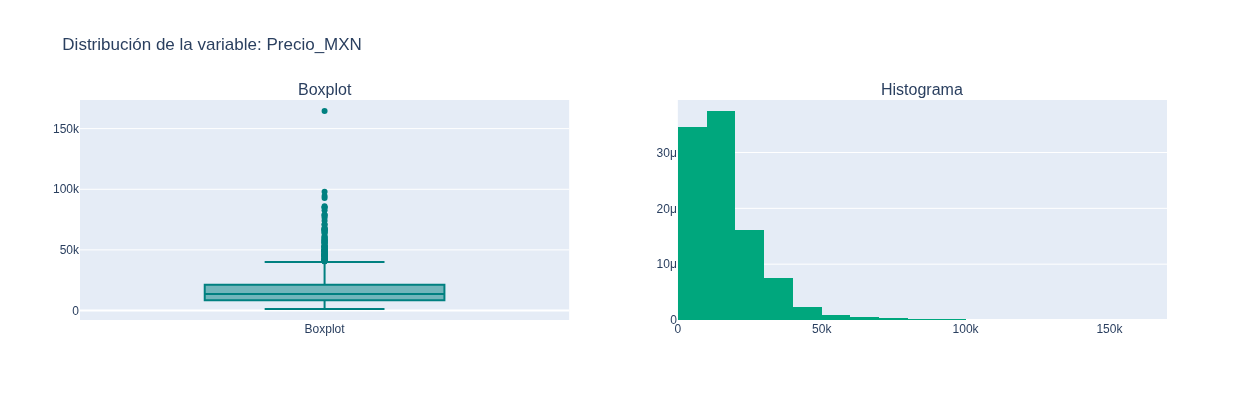

--- TABLA DE FRECUENCIAS DEL HISTOGRAMA: Precio_MXN ---


,Rango_Bin,Frecuencia_Conteo,Porcentaje_%
0,[1250.0 a 9413.9),675,30.63
1,[9413.9 a 17577.8),784,35.57
2,[17577.8 a 25741.7),360,16.33
3,[25741.7 a 33905.6),204,9.26
4,[33905.6 a 42069.5),100,4.54
5,[42069.5 a 50233.4),34,1.54
6,[50233.4 a 58397.3),17,0.77
7,[58397.3 a 66561.2),11,0.50
8,[66561.2 a 74725.1),7,0.32
9,[74725.1 a 82889.0),5,0.23


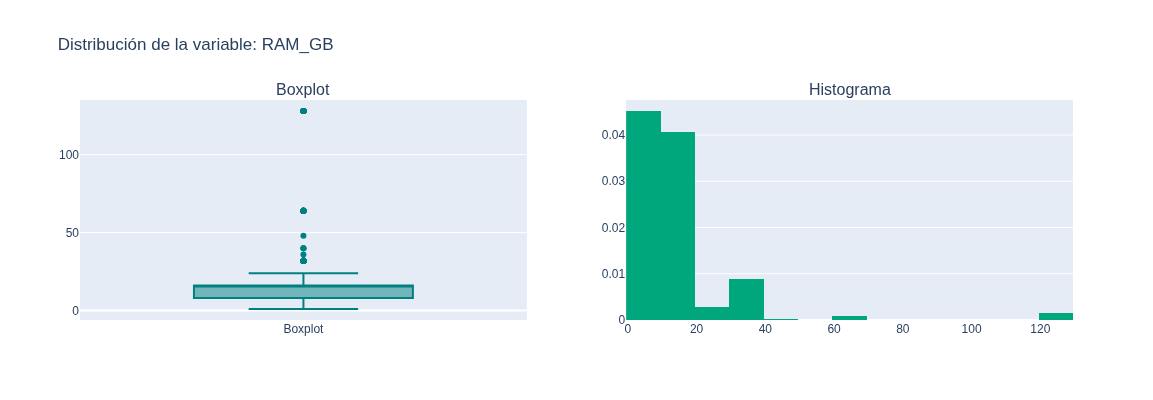

--- TABLA DE FRECUENCIAS DEL HISTOGRAMA: RAM_GB ---


,Rango_Bin,Frecuencia_Conteo,Porcentaje_%
0,[1.0 a 7.35),293,13.29
1,[7.35 a 13.7),733,33.26
2,[13.7 a 20.05),870,39.47
3,[20.05 a 26.4),60,2.72
4,[26.4 a 32.75),193,8.76
5,[32.75 a 39.1),1,0.05
6,[39.1 a 45.45),3,0.14
7,[45.45 a 51.8),1,0.05
8,[51.8 a 58.15),0,0.00
9,[58.15 a 64.5),18,0.82


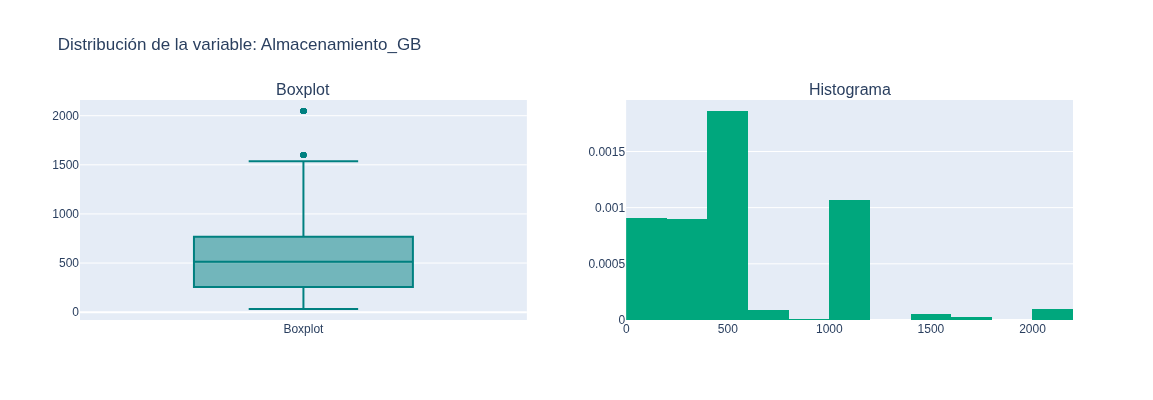

--- TABLA DE FRECUENCIAS DEL HISTOGRAMA: Almacenamiento_GB ---


,Rango_Bin,Frecuencia_Conteo,Porcentaje_%
0,[32.0 a 132.8),388,17.60
1,[132.8 a 233.6),16,0.73
2,[233.6 a 334.4),381,17.29
3,[334.4 a 435.2),14,0.64
4,[435.2 a 536.0),813,36.89
5,[536.0 a 636.8),21,0.95
6,[636.8 a 737.6),18,0.82
7,[737.6 a 838.4),4,0.18
8,[838.4 a 939.2),0,0.00
9,[939.2 a 1040.0),428,19.42


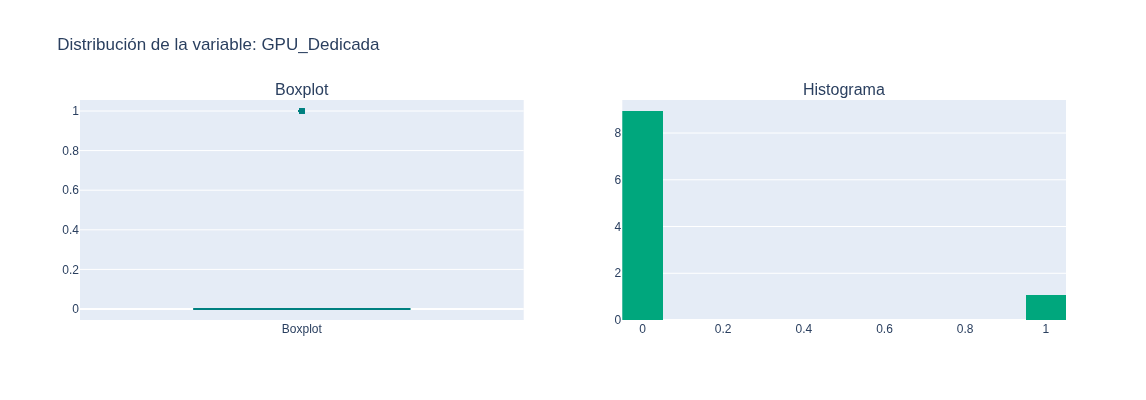

--- TABLA DE FRECUENCIAS DEL HISTOGRAMA: GPU_Dedicada ---


,Rango_Bin,Frecuencia_Conteo,Porcentaje_%
0,[0.0 a 0.05),1971,89.43
1,[0.05 a 0.1),0,0.00
2,[0.1 a 0.15),0,0.00
3,[0.15 a 0.2),0,0.00
4,[0.2 a 0.25),0,0.00
5,[0.25 a 0.3),0,0.00
6,[0.3 a 0.35),0,0.00
7,[0.35 a 0.4),0,0.00
8,[0.4 a 0.45),0,0.00
9,[0.45 a 0.5),0,0.00


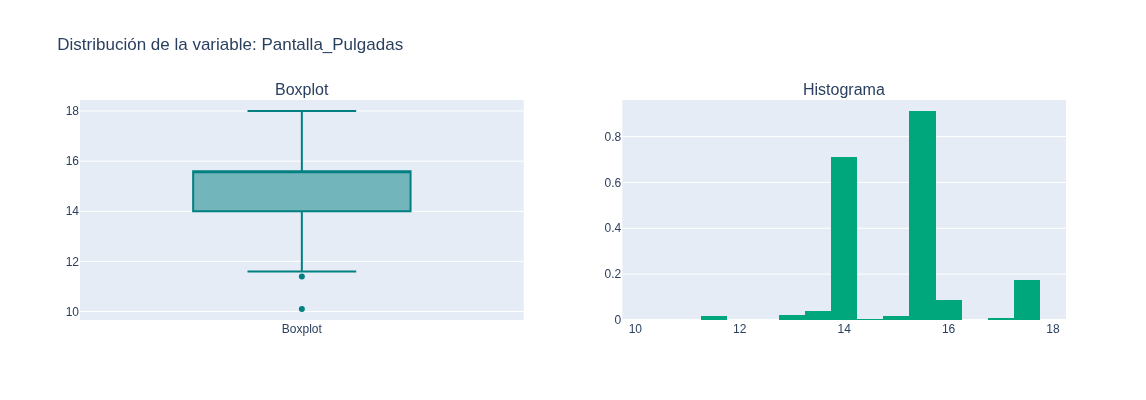

--- TABLA DE FRECUENCIAS DEL HISTOGRAMA: Pantalla_Pulgadas ---


,Rango_Bin,Frecuencia_Conteo,Porcentaje_%
0,[10.1 a 10.5),1,0.10
1,[10.5 a 10.89),0,0.00
2,[10.89 a 11.28),0,0.00
3,[11.28 a 11.68),8,0.82
4,[11.68 a 12.08),0,0.00
5,[12.08 a 12.47),1,0.10
6,[12.47 a 12.86),1,0.10
7,[12.86 a 13.26),10,1.03
8,[13.26 a 13.66),19,1.95
9,[13.66 a 14.05),338,34.77


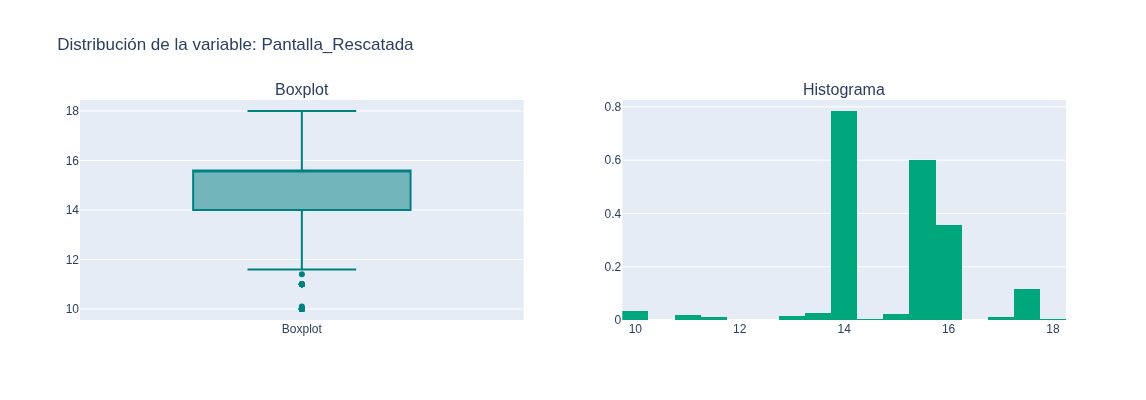

--- TABLA DE FRECUENCIAS DEL HISTOGRAMA: Pantalla_Rescatada ---


,Rango_Bin,Frecuencia_Conteo,Porcentaje_%
0,[10.0 a 10.4),24,1.62
1,[10.4 a 10.8),0,0.00
2,[10.8 a 11.2),14,0.95
3,[11.2 a 11.6),1,0.07
4,[11.6 a 12.0),7,0.47
5,[12.0 a 12.4),1,0.07
6,[12.4 a 12.8),1,0.07
7,[12.8 a 13.2),10,0.68
8,[13.2 a 13.6),19,1.28
9,[13.6 a 14.0),0,0.00


/tmp/ipykernel_6954/1746379533.py:93: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_cat = self.df.select_dtypes(include=['object', 'category']).columns


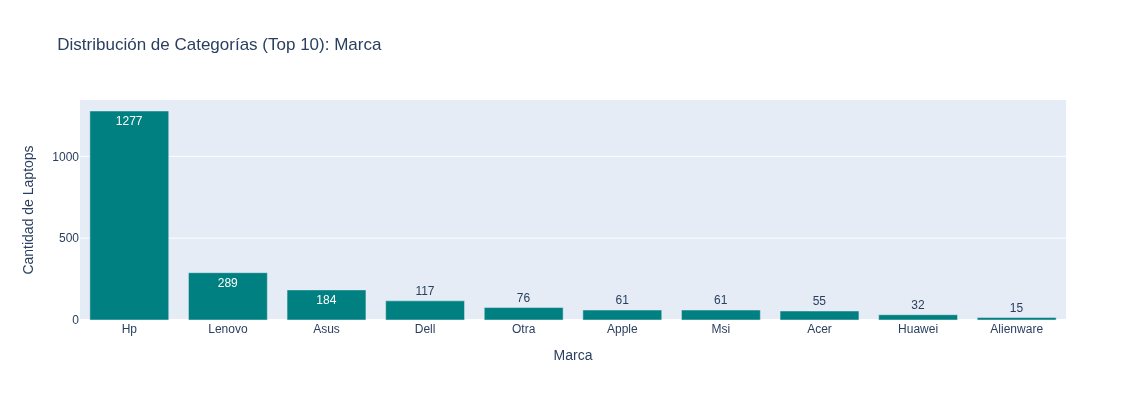

--- TABLA DE CATEGORÍAS: Marca ---


,Marca,Conteo,Porcentaje_%
0,Hp,1277,57.94
1,Lenovo,289,13.11
2,Asus,184,8.35
3,Dell,117,5.31
4,Otra,76,3.45
5,Apple,61,2.77
6,Msi,61,2.77
7,Acer,55,2.50
8,Huawei,32,1.45
9,Alienware,15,0.68


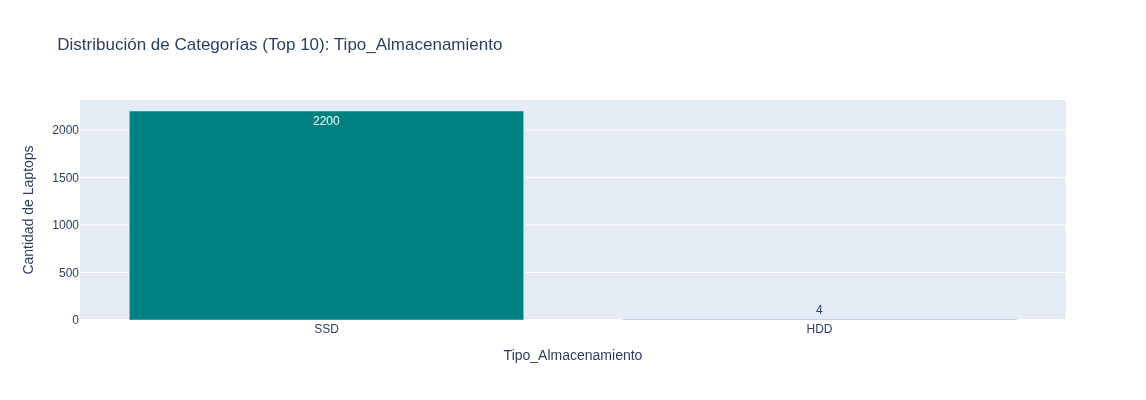

--- TABLA DE CATEGORÍAS: Tipo_Almacenamiento ---


,Tipo_Almacenamiento,Conteo,Porcentaje_%
0,SSD,2200,99.82
1,HDD,4,0.18


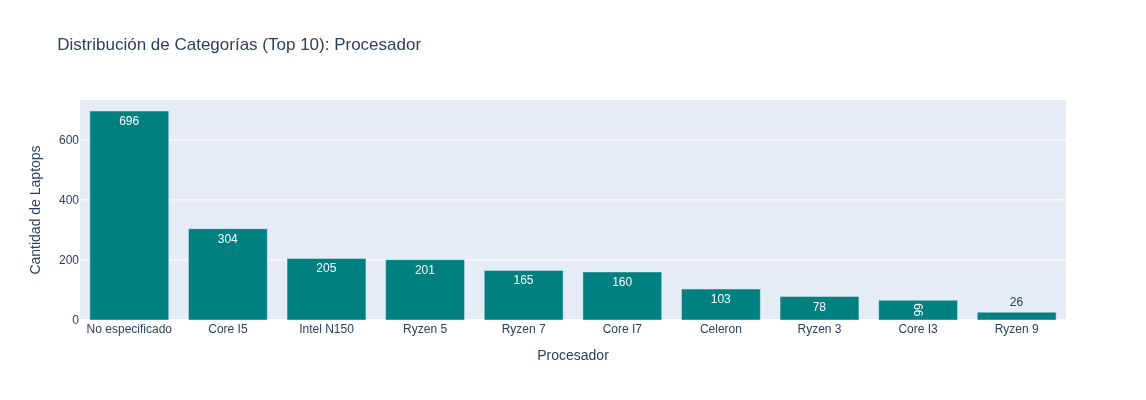

--- TABLA DE CATEGORÍAS: Procesador ---


,Procesador,Conteo,Porcentaje_%
0,No especificado,696,31.58
1,Core I5,304,13.79
2,Intel N150,205,9.30
3,Ryzen 5,201,9.12
4,Ryzen 7,165,7.49
5,Core I7,160,7.26
6,Celeron,103,4.67
7,Ryzen 3,78,3.54
8,Core I3,66,2.99
9,Ryzen 9,26,1.18


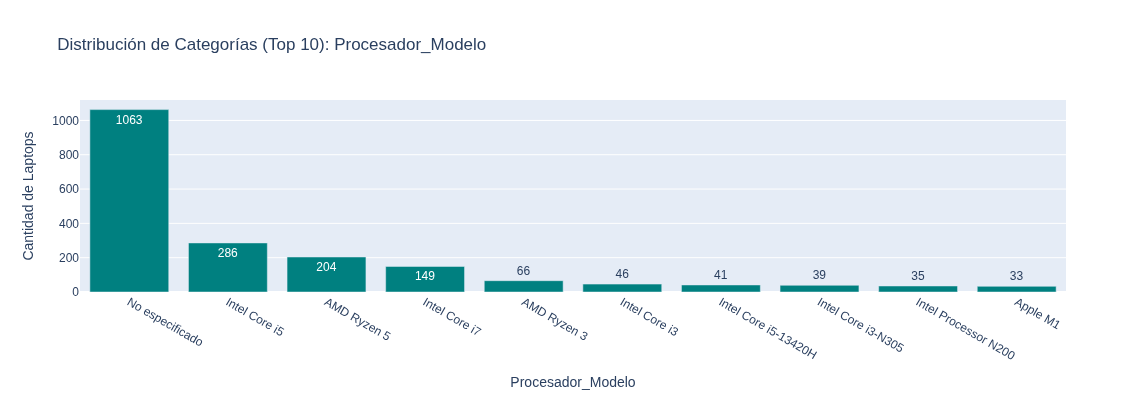

--- TABLA DE CATEGORÍAS: Procesador_Modelo ---


,Procesador_Modelo,Conteo,Porcentaje_%
0,No especificado,1063,48.23
1,Intel Core i5,286,12.98
2,AMD Ryzen 5,204,9.26
3,Intel Core i7,149,6.76
4,AMD Ryzen 3,66,2.99
5,Intel Core i3,46,2.09
6,Intel Core i5-13420H,41,1.86
7,Intel Core i3-N305,39,1.77
8,Intel Processor N200,35,1.59
9,Apple M1,33,1.50


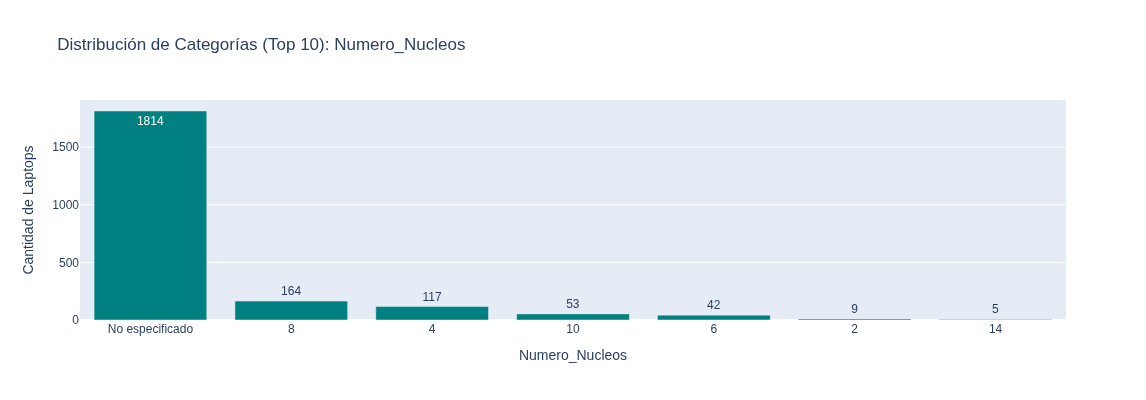

--- TABLA DE CATEGORÍAS: Numero_Nucleos ---


,Numero_Nucleos,Conteo,Porcentaje_%
0,No especificado,1814,82.30
1,8,164,7.44
2,4,117,5.31
3,10,53,2.40
4,6,42,1.91
5,2,9,0.41
6,14,5,0.23


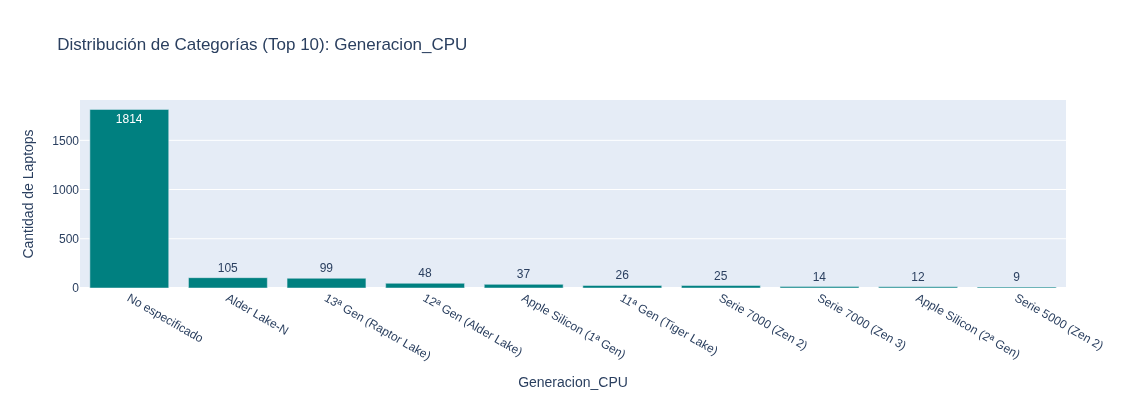

--- TABLA DE CATEGORÍAS: Generacion_CPU ---


,Generacion_CPU,Conteo,Porcentaje_%
0,No especificado,1814,82.30
1,Alder Lake-N,105,4.76
2,13ª Gen (Raptor Lake),99,4.49
3,12ª Gen (Alder Lake),48,2.18
4,Apple Silicon (1ª Gen),37,1.68
5,11ª Gen (Tiger Lake),26,1.18
6,Serie 7000 (Zen 2),25,1.13
7,Serie 7000 (Zen 3),14,0.64
8,Apple Silicon (2ª Gen),12,0.54
9,Serie 5000 (Zen 2),9,0.41


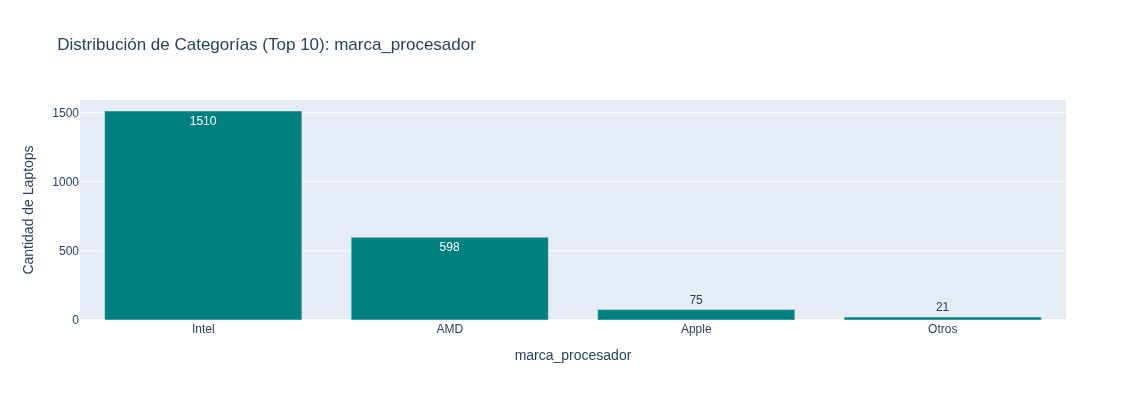

--- TABLA DE CATEGORÍAS: marca_procesador ---


,marca_procesador,Conteo,Porcentaje_%
0,Intel,1510,68.51
1,AMD,598,27.13
2,Apple,75,3.40
3,Otros,21,0.95


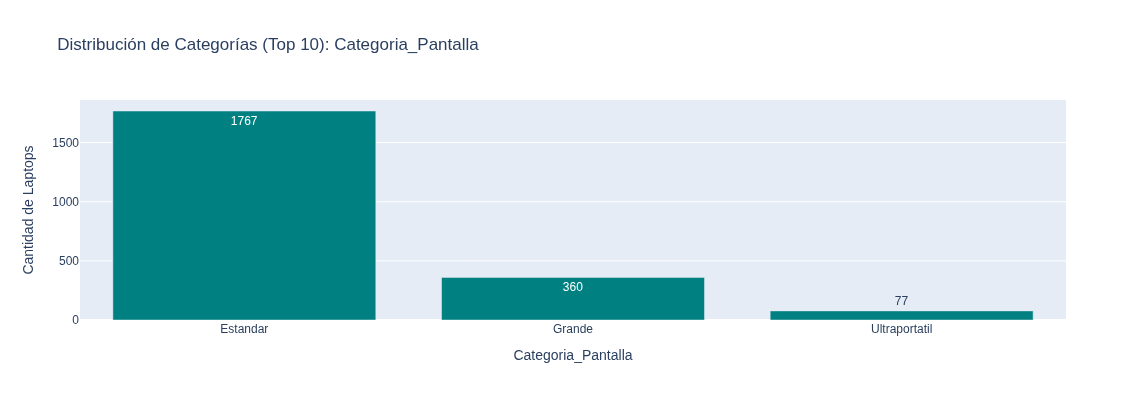

--- TABLA DE CATEGORÍAS: Categoria_Pantalla ---


,Categoria_Pantalla,Conteo,Porcentaje_%
0,Estandar,1767,80.17
1,Grande,360,16.33
2,Ultraportatil,77,3.49


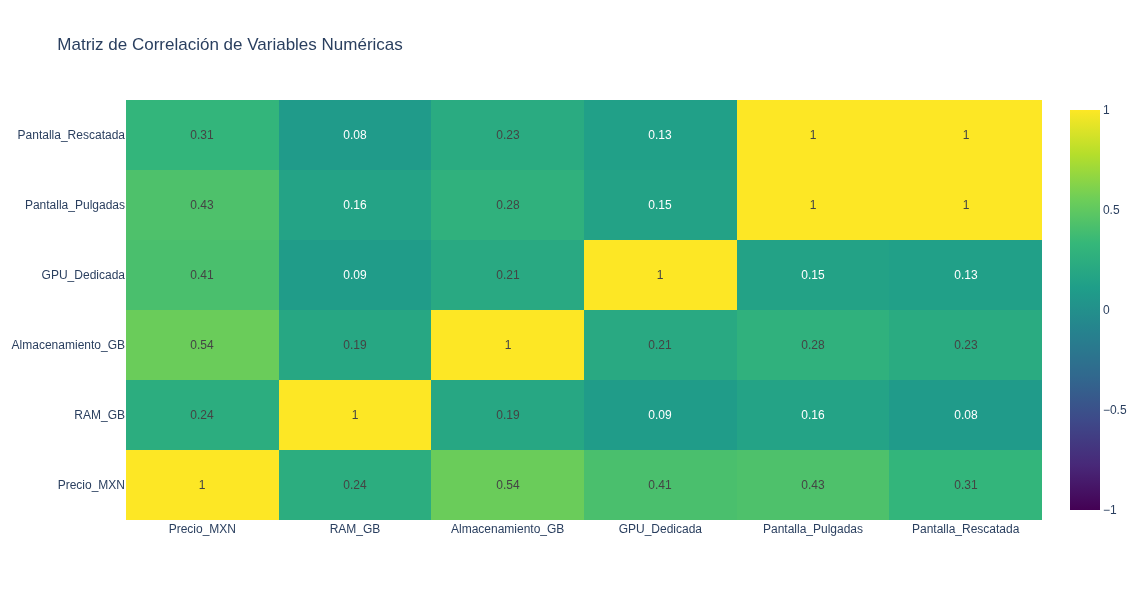

In [52]:
# Instanciar con la versión mejorada de la clase
eda = Analyze(df_laptops_oro)

# 1. Graficar TODAS las variables numéricas (RAM_GB, Almacenamiento_GB, Pantalla_Pulgadas, Precio_MXN)
eda.plot_all_numeric()

# 2. Graficar TODAS las variables categóricas (Marca, marca_procesador, Tipo_Almacenamiento)
eda.plot_categoricals()

# 3. Mostrar la Matriz de Correlación
eda.cor_matrix()

Observaciones

* El 89.43% de los equipos no cuenta con GPU dedicada, lo que significa que la clase "Gama Alta" o "Gaming" será una clase minoritaria.
* La RAM se concentra en 8 GB y 16 GB (acumulando el 72.73% de la muestra).
* El precio tiene un fuerte sesgo a la derecha (asimetría positiva). El 66.2% de las laptops cuestan menos de 17,577 pesos, pero existe una "cola" de equipos con precios atípicos que superan los $100,000 MXN.
* Las variables de RAM_GB y Almacenamiento_GB tienen "brincos" de escala grandes.
* Más del 48% de los procesadores tienen la categoría de "No especificado"

Estatagias:

* Para casos como este podemos usar las métricas F1-Score, Precisión y Recall para evaluar qué tan bien el modelo detecta la clase minoritaria.
* También podemos ajustar el hiperparámetro de peso de clases para penalizar más los errores en la predicción de la clase minoritaria.
* Dado que el 80.35% de las pantallas se concentra en 14" y 15.6", podemos convertir esta variable numérica en categórica ("Ultra-portátil < 14", "Estándar 14-15", "Grande >15")
* Para la variable del precio podriamos utilizar la transformación logaritmica para tratar de hacerla más simétrica y a la vez podemos usar el modelo de random forest para el modelo de regresión y así evitar afectaciones debidas al sesgo.
* Considerando que para las variables de RAM_GB y Almacenamiento_GB tenemos brincos en la escala podemos usar MinMaxEscaler para estandarizar las escalas.
* Podemos usar una transformación logarítmica para la RAM_GB y Almacenamiento_GB pues su aumento es escalonado y no continuo.
* Para ayudar al modelo a identificar la jerarquía entre los procesadores podemos generar un nuevo campo para clasificarlos. Dado que la mayoría de los procesadores tiene la categoria de "No especificado" podemos valernos de el valor de la RAM considerando que modelos con menor RAM estarían asociados a laptops con procesadores de gamas más bajas y viceversa. 


In [53]:
df_laptops_oro.to_csv("muestra.csv", index=False)

## Ingenieria de variables

Definimos la jerarquía entre procesadores. 

In [54]:
def extraer_cpu_tier_robusto(row):
    # 1. Búsqueda Combinada: Unimos el Nombre de la publicación y el Modelo de Procesador
    texto = str(row.get('Nombre', '')) + " " + str(row.get('Procesador_Modelo', ''))
    texto = texto.upper()
    
    # Patrones de Gama Alta
    if re.search(r'\b(I9|I7|RYZEN 9|RYZEN 7|M1|M2|M3|M4|ULTRA 7|ULTRA 9)\b', texto):
        return 3
    # Patrones de Gama Media
    elif re.search(r'\b(I5|RYZEN 5|ULTRA 5)\b', texto):
        return 2
    # Patrones de Gama Baja / Entrada
    elif re.search(r'\b(I3|RYZEN 3|CELERON|PENTIUM|ATHLON|N100|N200|N305|N95|N97|N4020|N4000|N50|N150)\b', texto):
        return 1
        
    # 2. Inferencia Lógica (Fallback para el 48% "No especificado")
    # Si las expresiones regulares fallan, usamos la RAM como proxy del procesador
    ram = row.get('RAM_GB', 0)
    
    if pd.isna(ram):
        return 1
    elif ram >= 16:
        # Laptops con 16GB o más suelen emparejarse con CPUs de gama media-alta o alta
        return 3 
    elif ram >= 8:
        # 8GB es el estándar indiscutible de la gama media actual
        return 2 
    else:
        # Laptops con 4GB o menos pertenecen a la gama de entrada
        return 1 



In [55]:
# Aplicamos la función usando axis=1 para poder evaluar múltiples columnas a la vez
df_laptops_oro['CPU_Tier'] = df_laptops_oro.apply(extraer_cpu_tier_robusto, axis=1)

# Verificación de la nueva distribución
print(df_laptops_oro['CPU_Tier'].value_counts(normalize=True) * 100)

CPU_Tier
2   34.66
1   33.62
3   31.72
Name: proportion, dtype: float64


Notamos que nuestro procedimiento ha podido clasificar los procesadores en 3 categorias más o menos balanceadas a pesar de que teniamos un 48% de procesadores con categoría "No especificado"

Dado que buscamos usar un clasificador para asignar etiquetas a los equipos en este punto podriamos usar dos métodos distintos para generar la variable objetivo para el clasificador. 

1.- Etiquetado por características técnicas: Consideramos las características de los equipos y los clasificamos en gama alta, media y baja.  
2.- Etiquetado por modelo no supervisado: Se generan clusters a los que dadas sus características se les asignan las etiquetas correspondientes. 

Si bien la segunda opción nos podria ayudar a descubrir nuevos grupos y a clasificar equipos con características "anomalas" como en equipos reacondicionados (que tuvieran un procesador de gama alta y poca memoria ram por ejemplo), debemos considerar que en las siguientes fases del proyecto un LLM tendrá que asignar un equipo al usuario con base en su descripción por lo que requerirá hacer uso de las características técnicas de los equipos, mientras que en el otro caso habría que explicar al LLM las características de los centroides.   


In [56]:
def asignar_gama_tecnica(row):
    gpu = row.get('GPU_Dedicada', 0)
    ram = row.get('RAM_GB', 0)
    alm = row.get('Almacenamiento_GB', 0)
    cpu = row.get('CPU_Tier', 1)
    
    # Regla 1: Gama Alta (Tiene GPU dedicada O tiene hardware top balanceado)
    if (pd.notna(gpu) and gpu > 0) or (ram >= 16 and alm >= 512 and cpu == 3):
        return 'Alta'
    
    # Regla 2: Gama Media (Mínimo 8GB de RAM y un procesador al menos de gama media)
    elif ram >= 8 and cpu >= 2:
        return 'Media'
    
    # Regla 3: Gama Baja (Equipos de entrada, ofimática básica, Chromebooks)
    else:
        return 'Baja'



In [57]:
df_laptops_oro['Target_Gama'] = df_laptops_oro.apply(asignar_gama_tecnica, axis=1)
print("Distribución de la Variable Objetivo:")
print(df_laptops_oro['Target_Gama'].value_counts(normalize=True) * 100)

Distribución de la Variable Objetivo:
Target_Gama
Media   34.94
Baja    34.85
Alta    30.22
Name: proportion, dtype: float64


Considerando los "saltos" en la magnitud de en la memoria RAM 4,8,16, etc. Podemos evitarlos si  aplicamos un logaritmo base 2,  te de tal modo que obtengamos:

* $log_2(8) = 3$
* $log_2(16) = 4$
* $log_2(32) = 5$

de este modo el crecimiento de la memoria RAM crece en saltos de solo una unidad permitiendo tener magnitudes más manejables para el modelo 

In [58]:
# Transformación Logarítmica Base 2 para RAM y Almacenamiento
df_laptops_oro['Log2_RAM'] = np.log2(df_laptops_oro['RAM_GB'])
df_laptops_oro['Log2_Almacenamiento'] = np.log2(df_laptops_oro['Almacenamiento_GB'])

Por otro lado, el tamaño de la pantalla podemos convertirlo a una variable categorica con valores: Ultraportatil, Estándar y Grande. 
Esto gracias que no es una variable continua y son pocos los valores fijos. Esto tiene la finalidad de que su uso sea más eficaz en el modelo 

In [59]:
# Discretización de la pantalla
def categorizar_pantalla(pulgadas):
    if pd.isna(pulgadas):
        return 'Desconocida'
    elif pulgadas < 14.0:
        return 'Ultraportatil'
    elif pulgadas <= 15.6:
        return 'Estandar'
    else:
        return 'Grande'

df_laptops_oro['Pantalla_Rescatada'] = df_laptops_oro['Pantalla_Rescatada'].apply(categorizar_pantalla)

In [60]:
print(df_laptops_oro['Categoria_Pantalla'].value_counts(normalize=True) * 100)

Categoria_Pantalla
Estandar        80.17
Grande          16.33
Ultraportatil    3.49
Name: proportion, dtype: float64


Notemos que tenemos categorias desequilibradas donde el tamaño "Estandar" concertra el 80% de los registros. Hay que considerar que para fines del modelo de clasificación esta variable pueda no ser considerada para la predicción de la variable obtetivo relacionada a la gama de la laptop (podemos tener laptops de gama alta que sean pequeñas). ESto lo podemos comprobar más adelante con el proceso de feature importance y de este modo esta variable no afecte a las predicciones del modelo. 

In [61]:
df_laptops_oro.columns

Index(['Marca', 'Nombre', 'Precio_MXN', 'RAM_GB', 'Almacenamiento_GB',
       'Tipo_Almacenamiento', 'Procesador', 'GPU_Dedicada',
       'Pantalla_Pulgadas', 'Procesador_Modelo', 'Numero_Nucleos',
       'Generacion_CPU', 'marca_procesador', 'Pantalla_Rescatada',
       'Categoria_Pantalla', 'CPU_Tier', 'Target_Gama', 'Log2_RAM',
       'Log2_Almacenamiento'],
      dtype='str')

In [62]:
# Crear la variable objetivo basada en cuantiles de PRECIO REAL (3 tercios del mercado)
# Esto divide tus datos en 3 rangos de precio proporcionales: Económico (0), Medio (1), Premium (2)
df_laptops_oro['Target_Gama_Precio'] = pd.qcut(df_laptops_oro['Precio_MXN'], q=3, labels=[0, 1, 2])

## Encoding

In [63]:
# 1. One-Hot Encoding para variables nominales (Marca y Pantalla)
# Solo tomamos las top marcas para no crear cientos de columnas
top_marcas = df_laptops_oro['Marca'].value_counts().head(10).index
df_laptops_oro['Marca_Agrupada'] = df_laptops_oro['Marca'].where(df_laptops_oro['Marca'].isin(top_marcas), 'Otra')

df_rf = pd.get_dummies(df_laptops_oro, columns=['Marca_Agrupada', 'Categoria_Pantalla'], drop_first=True)

# 2. Codificación Ordinal de la variable Objetivo
mapa_gama = {'Baja': 0, 'Media': 1, 'Alta': 2}
df_rf['Target_Gama_Codificada'] = df_rf['Target_Gama'].map(mapa_gama)

In [64]:
#df_rf.to_csv("rf.csv", index=False)

## Clasificación determinista 

In [65]:
import pandas as pd
import numpy as np

def asignar_gama_tecnica(row):
    # Condición Gama Alta: Procesador Top (Tier 3) O (GPU Dedicada y mucha RAM)
    if row['CPU_Tier'] == 3 or (row['GPU_Dedicada'] == 1 and row['Log2_RAM'] >= 4): # Log2_RAM 4 = 16GB
        return 'Alta'
    
    # Condición Gama Media: Procesador Medio (Tier 2) y al menos 8GB RAM (Log2_RAM >= 3)
    elif row['CPU_Tier'] >= 2 and row['Log2_RAM'] >= 3:
        return 'Media'
    
    # Condición Gama Baja: Todo lo que esté por debajo de los estándares anteriores
    else:
        return 'Baja'

# Aplicamos la regla a todo el dataset original
df_rf['Gama_Tecnica'] = df_rf.apply(asignar_gama_tecnica, axis=1)

print("Distribución de equipos según su hardware real:")
print(df_rf['Gama_Tecnica'].value_counts())

Distribución de equipos según su hardware real:
Gama_Tecnica
Baja     762
Alta     744
Media    698
Name: count, dtype: int64


## Modelo de regresión

In [66]:
# Seleccionamos dinámicamente las columnas creadas por get_dummies y las transformadas
columnas_modelo = ['Log2_RAM', 'Log2_Almacenamiento', 'CPU_Tier', 'GPU_Dedicada'] + \
                  [col for col in df_rf.columns if col.startswith('Marca_Agrupada_') or col.startswith('Categoria_Pantalla_')]

In [67]:
X = df_rf[columnas_modelo]
y_reg = df_rf['Precio_MXN'] # Asegúrate de que esta columna sea la del precio numérico real

In [68]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)


In [69]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_reg, y_train_reg)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [70]:

# 4. Predicciones sobre el set de prueba
y_pred_reg = rf_reg.predict(X_test_reg)

# 5. Evaluación del modelo
r2 = r2_score(y_test_reg, y_pred_reg)
mae = mean_absolute_error(y_test_reg, y_pred_reg)

print("=" * 50)
print("RENDIMIENTO DEL MODELO DE MERCADO (REGRESIÓN):")
print(f"Precisión general (R2): {r2:.2f} (1.0 es perfecto)")
print(f"Margen de error promedio (MAE): ${mae:,.2f}")
print("=" * 50)



RENDIMIENTO DEL MODELO DE MERCADO (REGRESIÓN):
Precisión general (R2): 0.49 (1.0 es perfecto)
Margen de error promedio (MAE): $5,434.89


In [71]:

# 1. Generar predicciones para ambos conjuntos
y_pred_train_reg = rf_reg.predict(X_train_reg)
y_pred_test_reg = rf_reg.predict(X_test_reg)

# 2. Calcular métricas para Entrenamiento (Train)
r2_train = r2_score(y_train_reg, y_pred_train_reg)
mae_train = mean_absolute_error(y_train_reg, y_pred_train_reg)
rmse_train = np.sqrt(mean_squared_error(y_train_reg, y_pred_train_reg))

# 3. Calcular métricas para Prueba (Test)
r2_test = r2_score(y_test_reg, y_pred_test_reg)
mae_test = mean_absolute_error(y_test_reg, y_pred_test_reg)
rmse_test = np.sqrt(mean_squared_error(y_test_reg, y_pred_test_reg))

# 4. Imprimir el reporte comparativo
print("=" * 55)
print("COMPARATIVA DE MÉTRICAS: ENTRENAMIENTO VS PRUEBA")
print("=" * 55)
print("▶ ENTRENAMIENTO (Train):")
print(f"  - R² (Precisión): {r2_train:.2f}")
print(f"  - MAE (Error Promedio): ${mae_train:,.2f} MXN")
print(f"  - RMSE (Error Cuadrático): ${rmse_train:,.2f} MXN")
print("-" * 55)
print("▶ PRUEBA (Test):")
print(f"  - R² (Precisión): {r2_test:.2f}")
print(f"  - MAE (Error Promedio): ${mae_test:,.2f} MXN")
print(f"  - RMSE (Error Cuadrático): ${rmse_test:,.2f} MXN")
print("=" * 55)

COMPARATIVA DE MÉTRICAS: ENTRENAMIENTO VS PRUEBA
▶ ENTRENAMIENTO (Train):
  - R² (Precisión): 0.79
  - MAE (Error Promedio): $3,575.41 MXN
  - RMSE (Error Cuadrático): $5,455.06 MXN
-------------------------------------------------------
▶ PRUEBA (Test):
  - R² (Precisión): 0.49
  - MAE (Error Promedio): $5,434.89 MXN
  - RMSE (Error Cuadrático): $10,319.76 MXN


In [72]:
# 1. Entrenamos un modelo "Podado" (Regularizado) para evitar la memorización
rf_reg_podado = RandomForestRegressor(
    n_estimators=100, 
    max_depth=8,            # Límite de ramas: evita que aprenda detalles irrelevantes
    min_samples_leaf=5,     # Obliga a que cada regla aplique al menos a 5 laptops similares
    random_state=42
)
rf_reg_podado.fit(X_train_reg, y_train_reg)

# 2. Generamos predicciones nuevamente
y_pred_train_podado = rf_reg_podado.predict(X_train_reg)
y_pred_test_podado = rf_reg_podado.predict(X_test_reg)

# 3. Calculamos el nuevo R2
r2_train_podado = r2_score(y_train_reg, y_pred_train_podado)
r2_test_podado = r2_score(y_test_reg, y_pred_test_podado)

print("=" * 55)
print("NUEVO MODELO REGULARIZADO (R²)")
print(f"  - Entrenamiento (Train): {r2_train_podado:.2f}")
print(f"  - Prueba (Test):         {r2_test_podado:.2f}")
print("=" * 55)

NUEVO MODELO REGULARIZADO (R²)
  - Entrenamiento (Train): 0.68
  - Prueba (Test):         0.50


In [73]:
a


NameError: name 'a' is not defined

---

## Random Forest (Modelo de clasificación)

### Variables relevantes

In [ ]:
# Seleccionamos dinámicamente las columnas creadas por get_dummies y las transformadas
columnas_modelo = ['Log2_RAM', 'Log2_Almacenamiento', 'CPU_Tier', 'GPU_Dedicada'] + \
                  [col for col in df_rf.columns if col.startswith('Marca_Agrupada_') or col.startswith('Categoria_Pantalla_')]

In [ ]:
X = df_rf[columnas_modelo]
y = df_rf['Target_Gama_Precio']

In [ ]:
# División en Entrenamiento (80%) y Prueba (20%)
# stratify=y asegura que la proporción de Gama Alta, Media y Baja se mantenga en ambos sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Entrenamiento del Modelo Base
rf_clf_precio = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_clf_precio.fit(X_train, y_train)

In [ ]:
# Extracción y Cálculo del Feature Importance
df_importancia_precio = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf_clf_precio.feature_importances_
}).sort_values(by='Importancia', ascending=False)

In [ ]:
print("Top 10 Variables más importantes para definir el PRECIO REAL de Mercado:")
print(df_importancia_precio.head(10).to_string(index=False))

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importancia', 
    y='Variable', 
    data=df_importancia_precio.head(10), 
    palette='viridis'
)
plt.title('Importancia de Variables según el PRECIO REAL (Mercado)')
plt.xlabel('Peso en la determinación del precio')
plt.ylabel('Componente / Atributo')
plt.tight_layout()
plt.show()

Como podemos observar el almacenamiento, la memoria RAM y el procesador son las características más importantes para determinar el precio de una laptop, mientras que la GPU y la marca quedan en segundo plano. 

In [ ]:
#Predicción sobre el set de prueba
y_pred_precio = rf_clf_precio.predict(X_test)

#Matriz de Confusión
plt.figure(figsize=(7, 5))
nombres_rangos = ['Económico (0)', 'Medio (1)', 'Premium (2)']
sns.heatmap(confusion_matrix(y_test, y_pred_precio), annot=True, fmt='d', cmap='Greens', 
            xticklabels=nombres_rangos, yticklabels=nombres_rangos)
plt.title('Matriz de Confusión - Predicción de Rangos de Precio')
plt.xlabel('Predicción del Algoritmo')
plt.ylabel('Rango de Precio Real')
plt.tight_layout()
plt.show()

In [ ]:
# Reporte de Clasificación
print("Reporte de Clasificación (Evaluación del Mercado Real):")
print(classification_report(y_test, y_pred_precio, target_names=['Económico', 'Medio', 'Premium']))

In [ ]:
# Obtener predicciones para ambos conjuntos
y_pred_train = rf_clf_precio.predict(X_train)
y_pred_test = rf_clf_precio.predict(X_test)

nombres_rangos = ['Económico', 'Medio', 'Premium']

# 2. Comparación rápida de Accuracy
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print("=" * 65)
print(f"ACCURACY GLOBAL:")
print(f"  - Entrenamiento (Train): {acc_train:.2%}")
print(f"  - Prueba (Test):        {acc_test:.2%}")
print("=" * 65)

# 3. Reporte de Métricas en TRAIN
print("\n" + "#" * 25 + " ENTRENAMIENTO (TRAIN) " + "#" * 25)
print(classification_report(y_train, y_pred_train, target_names=nombres_rangos))

# 4. Reporte de Métricas en TEST
print("\n" + "#" * 27 + " PRUEBA (TEST) " + "#" * 27)
print(classification_report(y_test, y_pred_test, target_names=nombres_rangos))

---

In [ ]:
# Unimos los datos reales con las predicciones
df_analisis = X_test.copy()
df_analisis['Precio_Real_Rango'] = y_test
df_analisis['Precio_Predicho_Rango'] = y_pred_precio
df_analisis['Nombre_Laptop'] = df_rf.loc[X_test.index, 'Nombre']
df_analisis['Precio_Original'] = df_rf.loc[X_test.index, 'Precio_MXN']

# 1. Filtramos Ganga: Hardware Premium vendido a precio Económico
gangas = df_analisis[(df_analisis['Precio_Real_Rango'] == 0) & (df_analisis['Precio_Predicho_Rango'] == 2)]
print("--- TOP GANGAS DETECTADAS (Hardware Premium a Precio Económico) ---")
print(gangas[['Nombre_Laptop', 'Precio_Original', 'CPU_Tier', 'Log2_RAM']].head())

# 2. Filtramos Sobreprecio: Hardware Económico vendido a precio Premium
sobreprecio = df_analisis[(df_analisis['Precio_Real_Rango'] == 2) & (df_analisis['Precio_Predicho_Rango'] == 0)]
print("\n--- EQUIPOS SOBREVALORADOS (Hardware Básico a Precio Premium) ---")
print(sobreprecio[['Nombre_Laptop', 'Precio_Original', 'CPU_Tier', 'Log2_RAM']].head())

In [ ]:
# 1. Guardar el objeto del modelo en un archivo .pkl
joblib.dump(rf_clf_precio, 'modelo_rf_laptops_precio.pkl')

# 2. (Recomendado) Guardar la lista de columnas empleadas en el entrenamiento
# Esto garantiza que siempre le pases al modelo las variables en el mismo orden exacto
joblib.dump(columnas_modelo, 'columnas_modelo.pkl')

print("¡Modelo y columnas guardados exitosamente!")